# Stage 3: Implementing an RAG System for Question Answering

## Libraries

In [1]:
!pip install pandas numpy seaborn matplotlib
!pip install sentence-transformers faiss-cpu --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 51.0 MB/s eta 0:00:00


In [2]:
import os
import re
import html
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter
from openai import OpenAI
import json
import time
from google.colab import userdata
from bs4 import BeautifulSoup
import requests
import networkx as nx
import matplotlib.cm as cm
from sentence_transformers import SentenceTransformer
import faiss

## Environment setup

In [3]:
ENV = "colab"

In [5]:
if ENV == "colab":
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


You also need your own `OPENAI_API_KEY`, https://platform.openai.com/api-keys.  Add it to Colab Secrets.

##

## Data preparation

In our previous stages we heavily normalized and cleaned our content columns. For RAG we need to preserve punctuation, but we still need to remove duplicates, strip html or urls.  So we load our initial dataset `CLT/ai_media_dataset_20250911.csv` (should be already in your folder from previous stages) and do a specific cleaning for later RAG implementation.

To keep your files organazied in your Google Drive create another folder `"stage_3"` inside `CLT`.

In [6]:
# -----------------------------
# 1) Load raw dataset
# -----------------------------
if ENV == "colab":
    raw_path = "/content/drive/My Drive/CLT/ai_media_dataset_20250911.csv"
else:
    raw_path = "data/ai_media_dataset_20250911.csv"

df = pd.read_csv(raw_path, encoding="utf-8", engine="python")

print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())


# -----------------------------
# 3) Restore tags as list (IMPORTANT)
# -----------------------------
def restore_tags(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

df['tags'] = df['tags'].apply(restore_tags)


# -----------------------------
# 4) Cleaning functions (RAG-safe)
# -----------------------------
def clean_text(text):
    text = str(text) if pd.notna(text) else ""

    # decode HTML entities
    text = html.unescape(text)

    # remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text(" ")

    # remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # normalize unicode quotes/dashes
    text = text.replace("\u2019", "'").replace("\u2018", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = text.replace("\u2013", "-").replace("\u2014", "-")

    # keep punctuation, remove weird junk
    text = re.sub(r"[^\w\s\.,;:!?\-\'\"()/]", " ", text)

    # normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


def clean_title(text):
    text = str(text) if pd.notna(text) else ""
    text = html.unescape(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


# -----------------------------
# 5) Apply cleaning
# -----------------------------
df['title'] = df['title'].apply(clean_title)
df['content'] = df['content'].apply(clean_text)


# -----------------------------
# 6) Remove bad rows
# -----------------------------
df = df.dropna(subset=['title', 'content'])

df = df[
    (df['title'].str.strip() != "") &
    (df['content'].str.strip() != "")
].copy()

# remove duplicates
df = df.drop_duplicates(subset=['title', 'content']).reset_index(drop=True)

print("Cleaned shape:", df.shape)


# -----------------------------
# 7) Optional: length filter (recommended)
# -----------------------------
df['word_count'] = df['content'].str.split().str.len()

# remove extremely short articles
df = df[df['word_count'] > 50].copy()

print("After length filter:", df.shape)


# -----------------------------
# 8) Drop helper column
# -----------------------------
df = df.drop(columns=['word_count'])


# -----------------------------
# 9) Save cleaned file
# -----------------------------
if ENV == "colab":
    save_path = "/content/drive/My Drive/CLT/stage_3/clean_title_content.csv"
else:
    save_path = "data/stage_3/clean_title_content.csv"

df.to_csv(save_path, index=False, encoding="utf-8")

print("Saved cleaned dataset to:", save_path)

Raw shape: (16527, 7)
Columns: ['Unnamed: 0', 'title', 'date', 'content', 'domain', 'url', 'tags']
Cleaned shape: (16527, 7)
After length filter: (16527, 8)
Saved cleaned dataset to: /content/drive/My Drive/CLT/stage_3/clean_title_content.csv


# 1. Q&A Dataset Construction
*Lead: Alla - Review: Bianca*

## 1.1 Data Loading


We load `clean_title_content.csv`  with columns `['date', 'domain', 'url', 'tags', 'title', 'content']`. Its clean, deduplicated and we removed special characters.

In [7]:
if ENV == "colab":
    norm_path = '/content/drive/My Drive/CLT/stage_3/clean_title_content.csv'
else:
    norm_path = 'data/stage_3/clean_title_content.csv'

df = pd.read_csv(norm_path, encoding='utf-8')

# Restore list columns serialized as strings by CSV
list_cols = ['tags']   # add more columns here if needed, e.g. ['tags', 'entities']

for col in list_cols:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: ast.literal_eval(x) if pd.notna(x) else []
        )


print("Loaded shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 3 rows:")
print(df.head(3))

Loaded shape: (16527, 7)

Columns:
['Unnamed: 0', 'title', 'date', 'content', 'domain', 'url', 'tags']

First 3 rows:
   Unnamed: 0                                              title        date  \
0       88571  Ricoh to provide customer support for Agility ...  2024-09-11   
1       92022  MTV VMAs 2024: Live shopping is coming to the ...  2024-09-11   
2       81522  Open-source imagery is transforming investigat...  2024-09-11   

                                             content           domain  \
0  'The Digit humanoid could work in distribution...   therobotreport   
1  'In this article', "When viewers tune in to th...             cnbc   
2  'Open-source online imagery can play a vital r...  theconversation   

                                                 url  \
0  https://www.therobotreport.com/ricoh-provides-...   
1  https://www.cnbc.com/2024/09/11/mtv-vmas-2024-...   
2  https://www.theconversation.com/open-source-im...   

                                           

## 1.2 Searching for most frequent tags
We began by exploring the distribution of tags in the AI Media Dataset to understand the thematic structure of the data. We extracted and normalized the tag information, then computed tag frequencies to identify the most prominent AI-related topics, such as generative AI, robotics, natural language processing, and governance. This step allowed us to assess topic coverage and detect potential imbalances in the dataset.

In [8]:
# Flatten list of tags
all_tags = [tag.lower() for tags in df['tags'] for tag in tags]

# Count frequencies
tag_counter = Counter(all_tags)

# Convert to DataFrame
tag_df = (
    pd.DataFrame(tag_counter.items(), columns=['tag', 'count'])
    .sort_values(by='count', ascending=False)
    .reset_index(drop=True)
)

print("Number of unique tags:", len(tag_df))
print(tag_df.head(20))

Number of unique tags: 956
                          tag  count
0                generativeai   4204
1                       video   3258
2          largelanguagemodel   3107
3             personalisation   2595
4                    planning   2464
5                      openai   2387
6            conversationalai   2267
7          militaryanddefense   2171
8                    robotics   2158
9                     chatgpt   2110
10             accountability   1735
11                  reasoning   1657
12                 finetuning   1286
13          autonomousdriving   1245
14                      audio   1182
15           quantumcomputing   1073
16               deeplearning   1071
17                        gpu   1047
18                     gemini   1042
19  naturallanguageprocessing   1025


Now we would search for text passages in content column which include this topics.

##1.3 Assign topic/s to each document
Next, we grouped related tags into broader topic categories (e.g., generative AI, robotics and autonomy, ethics and governance, technical AI). We assigned each document to a primary topic based on its associated tags. This topic assignment enabled us to perform stratified sampling, ensuring that the selected subset of documents represented a diverse range of AI themes rather than being dominated by a few high-frequency topics.

In [9]:
# =========================
# 2) Topic groups from your tags
# =========================
topic_groups = {
    "generative_ai": [
        "generativeai", "largelanguagemodel", "chatgpt", "openai", "gemini"
    ],
    "nlp": [
        "naturallanguageprocessing", "conversationalai"
    ],
    "robotics_autonomy": [
        "robotics", "autonomousdriving"
    ],
    "ethics_governance": [
        "accountability", "militaryanddefense"
    ],
    "technical_ai": [
        "deeplearning", "finetuning", "gpu"
    ],
    "reasoning_planning": [
        "reasoning", "planning"
    ],
    "applications": [
        "personalisation", "video", "audio"
    ],
    "emerging_tech": [
        "quantumcomputing"
    ]
}

# =========================
# 3) Assign each document to one or more topic groups
# =========================
def assign_topic_groups(tags):
    tags_lower = {str(t).strip().lower() for t in tags}
    matched = []
    for group, group_tags in topic_groups.items():
        if any(tag in tags_lower for tag in group_tags):
            matched.append(group)
    return matched

df['topic_groups'] = df['tags'].apply(assign_topic_groups)

# Keep only rows that match at least one topic group
df_topics = df[df['topic_groups'].apply(len) > 0].copy()

print("Rows with matched topic groups:", df_topics.shape[0])


Rows with matched topic groups: 14519


##1.4 Split content into sentences and paragraphs, create scores for passages
To select the most suitable passages, we applied a scoring mechanism. We prioritized passages based on criteria such as:

length (to avoid overly short or excessively long segments),
informational richness (presence of key entities, concepts, or claims),
and relevance to the assigned topic (based on tag overlap or keyword presence).


In [10]:
# =========================
# 4) Passage extraction from content
#    - prefer paragraphs
#    - fallback to sentence windows
# =========================
def normalize_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def split_paragraphs(text):
    # split on blank lines or paragraph-like breaks
    raw_parts = re.split(r'\n\s*\n|\r\n\s*\r\n', str(text))
    parts = [re.sub(r'\s+', ' ', p).strip() for p in raw_parts]
    return [p for p in parts if p]

def split_sentences(text):
    # simple sentence splitter
    text = re.sub(r'\s+', ' ', str(text)).strip()
    if not text:
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if s.strip()]

def score_passage(passage):
    """
    Higher score = better candidate for QA generation.
    Rewards informative, self-contained passages.
    """
    p = str(passage)
    word_count = len(p.split())

    # base length preference: target around 80-220 words
    if word_count < 40:
        length_score = -100
    elif 80 <= word_count <= 220:
        length_score = 30
    elif 40 <= word_count < 80 or 220 < word_count <= 300:
        length_score = 15
    else:
        length_score = 0

    # reward informative features
    feature_score = 0
    if re.search(r'\b(ai|artificial intelligence|model|models|robot|policy|regulation|ethics|openai|google|microsoft|meta|nvidia|chatgpt|llm)\b', p, re.I):
        feature_score += 10
    if re.search(r'\b\d{4}\b', p):  # year mention
        feature_score += 3
    if re.search(r'\b(because|however|while|although|but|therefore|raises|improves|reduces|enables|compared to)\b', p, re.I):
        feature_score += 6

    # penalize noisy passages
    noise_score = 0
    if p.count('|') > 2:
        noise_score -= 10
    if len(re.findall(r'[^\w\s.,;:!?()\'"-]', p)) > 20:
        noise_score -= 10

    return length_score + feature_score + noise_score

def extract_best_passage(text, min_words=60, max_words=220):
    """
    Try paragraph-based extraction first.
    If no good paragraph, fallback to sentence-window extraction.
    """
    text = str(text).strip()
    if not text:
        return None

    # paragraph-first strategy
    paragraphs = split_paragraphs(text)
    candidate_paragraphs = []

    for p in paragraphs:
        wc = len(p.split())
        if min_words <= wc <= max_words:
            candidate_paragraphs.append(p)

    if candidate_paragraphs:
        best = max(candidate_paragraphs, key=score_passage)
        return normalize_text(best)

    # if paragraphs too long/short, fallback to sentence windows
    sentences = split_sentences(text)
    if not sentences:
        return None

    windows = []
    n = len(sentences)

    # try windows of 3-6 sentences
    for window_size in range(3, 7):
        for i in range(n - window_size + 1):
            chunk = " ".join(sentences[i:i + window_size]).strip()
            wc = len(chunk.split())
            if min_words <= wc <= max_words:
                windows.append(chunk)

    if windows:
        best = max(windows, key=score_passage)
        return normalize_text(best)

    # last fallback: first max_words words if long enough
    words = text.split()
    if len(words) >= min_words:
        return " ".join(words[:max_words])

    return None

## 1.5 Create a balanced sample of passages by topic
We then selected the highest-scoring passages from each topic group to ensure both quality and diversity in the final dataset.

This process resulted in a balanced set of representative, high-quality passages that served as the foundation for generating grounded question–answer pairs including the topic



In [11]:
# =========================
# 5) Balanced document sampling by topic group
# =========================
TARGET_TOTAL = 80
TOPIC_NAMES = list(topic_groups.keys())
PER_TOPIC = max(6, TARGET_TOTAL // len(TOPIC_NAMES))

samples = []

for topic in TOPIC_NAMES:
    subset = df_topics[df_topics['topic_groups'].apply(lambda groups: topic in groups)].copy()
    if subset.empty:
        continue

    # shuffle for reproducibility
    subset = subset.sample(frac=1, random_state=42)

    # oversample candidates because some passages may fail extraction
    subset = subset.head(PER_TOPIC * 3).copy()
    subset['sampled_topic'] = topic
    samples.append(subset)

candidate_docs = pd.concat(samples).drop_duplicates(subset=['title', 'content']).reset_index(drop=True)

print("Candidate docs:", candidate_docs.shape)

# =========================
# 6) Extract one representative passage per sampled document
# =========================
candidate_docs['passage'] = candidate_docs['content'].apply(extract_best_passage)
candidate_docs['passage_word_count'] = candidate_docs['passage'].apply(lambda x: len(str(x).split()) if pd.notna(x) and x else 0)

selected = candidate_docs.dropna(subset=['passage']).copy()
selected = selected[selected['passage_word_count'] >= 60].copy()

print("Docs with extracted passages:", selected.shape)
# =========================
# 7) Re-balance final selection by topic
# =========================
final_parts = []

for topic in TOPIC_NAMES:
    subset = selected[selected['sampled_topic'] == topic].copy()
    if subset.empty:
        continue

    n = min(PER_TOPIC, len(subset))
    final_parts.append(subset.head(n))

selected_passages = pd.concat(final_parts).drop_duplicates(subset=['title', 'passage']).reset_index(drop=True)

# Trim to target total if needed
if len(selected_passages) > TARGET_TOTAL:
    selected_passages = selected_passages.sample(n=TARGET_TOTAL, random_state=42).reset_index(drop=True)

# Add ids
selected_passages.insert(0, 'passage_id', [f"p_{i:03d}" for i in range(1, len(selected_passages) + 1)])

# Keep useful columns
keep_cols = [
    'passage_id',
    'title',
    'sampled_topic',
    'tags',
    'passage',
    'passage_word_count'
]

# include optional metadata if present
for extra_col in ['date', 'source', 'url']:
    if extra_col in selected_passages.columns:
        keep_cols.insert(keep_cols.index('tags'), extra_col)

selected_passages = selected_passages[keep_cols].copy()

print("Final selected passages:", selected_passages.shape)
print(selected_passages['sampled_topic'].value_counts())
print(selected_passages[['passage_id', 'sampled_topic', 'title', 'passage_word_count']].head())



Candidate docs: (238, 9)
Docs with extracted passages: (238, 11)
Final selected passages: (80, 8)
sampled_topic
generative_ai         10
nlp                   10
robotics_autonomy     10
ethics_governance     10
technical_ai          10
reasoning_planning    10
applications          10
emerging_tech         10
Name: count, dtype: int64
  passage_id  sampled_topic  \
0      p_001  generative_ai   
1      p_002  generative_ai   
2      p_003  generative_ai   
3      p_004  generative_ai   
4      p_005  generative_ai   

                                               title  passage_word_count  
0  Generative AI for the Sceptics: Advice for 202...                  81  
1  66Degrees CEO On How Google AI Sales Grew 325 ...                 107  
2  Case Study: Optimizing Network Resilience with...                  89  
3  Spectra Logic Introduces 24G Optical SAS Switc...                  98  
4  Why the Stargate Project Must Take Environment...                  85  


## 1.6 Save selected passages

In [12]:
# =========================
# 8) Save result
# =========================
if ENV == "colab":
    save_path = '/content/drive/My Drive/CLT/stage_3/selected_passages.csv'
else:
    save_path = 'data/stage_3/selected_passages.csv'

selected_passages.to_csv(save_path, index=False, encoding='utf-8')
print("Saved to:", save_path)


# =========================
# 9) Optional: inspect a few passages
# =========================
for _, row in selected_passages.head(3).iterrows():
    print("\n" + "="*80)
    print("PASSAGE ID:", row['passage_id'])
    print("TOPIC:", row['sampled_topic'])
    print("TITLE:", row['title'])
    print("TAGS:", row['tags'])
    print("PASSAGE:", row['passage'][:800], "...")

Saved to: /content/drive/My Drive/CLT/stage_3/selected_passages.csv

PASSAGE ID: p_001
TOPIC: generative_ai
TITLE: Generative AI for the Sceptics: Advice for 2025 from a Veteran Unbeliever
TAGS: ['GenerativeAI', 'ChatGPT', 'FakeNews', 'Disinformation']
PASSAGE: Around the same time, I heard AI-generated music that sounded good. Within the same week, two literary contests in Bulgaria were won by AI-generated poems.", 'So, I did my research. Here' s what I' ve learned, fellow sceptics: Gen AI, as Douglas Adams would say, is a labor-saving device.', 'It doesn' t believe like the Electric Monk in all the things the modern world expects us to believe in, but it can process enormous amounts of data and produce human-usable summaries. ...

PASSAGE ID: p_002
TOPIC: generative_ai
TITLE: 66Degrees CEO On How Google AI Sales Grew 325 Percent
TAGS: ['Gemini', 'GoogleCloud', 'AIAgent', 'GenerativeAI', 'LargeLanguageModel', 'RAG', 'ContactCenterAI', 'Finetuning']
PASSAGE: 'Top Google partner 66degre

## 1.7. Generate 200 questions with LLM
We designed structured prompts to generate question–answer pairs from each passage. The prompts included the passage text along with contextual metadata (title, topic, and tags) to guide the model toward relevant AI topics. We required the model to produce a fixed number of Q&A pairs in a strict JSON format and to include different question types (factual, analytical, comparative).

We also constrained the prompts to encourage natural, user-like questions and to avoid meta-references (e.g., “in the passage” or “the author”). Through iterative refinement, we improved the quality, relevance, and grounding of the generated questions and answers.


----

Kommentar Marisa

----
**Correction (Section 1.7):** The original code used `qa_df.head(250)` to cap
the final Q&A dataset at 250 questions. Since questions are ordered by topic,
this silently dropped all `emerging_tech` questions (passage IDs p_071-p_080),
which were generated last. The fix replaces the hard cut with a stratified
sample of 250 questions that preserves topic balance.


ALTER CODE:



```


# ============================================================
# GENERATE TOPIC-ALAGED QUESTIONS FROM SELECTED PASSAGES
# - grounded in the "passage" column
# - guided by topic/title/tags
# - supports small test runs before full generation
# - if final QA file already exists -> load it and skip generation
# ============================================================

# -----------------------------
# 1) OpenAI client (Colab)
# -----------------------------
try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
except Exception:
    OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY not found. Add it in Colab Secrets.")

client = OpenAI(api_key=OPENAI_API_KEY)

# -----------------------------
# 2) Load selected passages
# -----------------------------
if ENV == "colab":
    passages_path = "/content/drive/My Drive/CLT/stage_3/selected_passages.csv"
else:
    passages_path = "data/stage_3/selected_passages.csv"

df = pd.read_csv(passages_path, encoding="utf-8", engine="python")

print("Loaded passages shape:", df.shape)
print("Columns:", df.columns.tolist())

# -----------------------------
# 3) Restore list columns if CSV serialized them as strings
# -----------------------------
def restore_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

for col in ["tags"]:
    if col in df.columns:
        df[col] = df[col].apply(restore_list)

# Add passage_id if missing
if "passage_id" not in df.columns:
    df = df.reset_index(drop=True)
    df.insert(0, "passage_id", [f"p_{i:03d}" for i in range(1, len(df) + 1)])

# Basic checks
required_cols = ["passage"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Optional metadata columns
if "title" not in df.columns:
    df["title"] = None
if "sampled_topic" not in df.columns:
    df["sampled_topic"] = None
if "tags" not in df.columns:
    df["tags"] = [[] for _ in range(len(df))]

# Drop empty passages
df["passage"] = df["passage"].astype(str).str.strip()
df = df[df["passage"] != ""].copy().reset_index(drop=True)

print("Usable passages:", df.shape)

# -----------------------------
# 4) SETTINGS
# -----------------------------
TEST_MODE = False           # True = small test, False = full generation
TEST_N_PASSAGES = 4        # how many passages to use in test mode
QUESTIONS_PER_PASSAGE = 4  # 50 passages x 4 = 200 questions
RANDOM_SEED = 42
MODEL_NAME = "gpt-4o-mini"
MAX_RETRIES = 3
SLEEP_SECONDS = 1.0
SAVE_EVERY = 5
VERBOSE = True
REUSE_EXISTING_OUTPUT = True

# Select subset
if TEST_MODE:
    run_df = df.sample(n=min(TEST_N_PASSAGES, len(df)), random_state=RANDOM_SEED).copy()
    print(f"TEST MODE ON -> {len(run_df)} passages")
else:
    run_df = df.copy()
    print(f"FULL MODE ON -> {len(run_df)} passages")

# -----------------------------
# 5) Output paths
# -----------------------------
suffix = "test" if TEST_MODE else "full"

if ENV == "colab":
    qa_output_path = f"/content/drive/My Drive/CLT/stage_3/qa_dataset_{suffix}.csv"
    qa_error_path = f"/content/drive/My Drive/CLT/stage_3/qa_errors_{suffix}.csv"
    qa_final_path = f"/content/drive/My Drive/CLT/stage_3/qa_dataset_{suffix}_final.csv"
else:
    qa_output_path = f"data/stage_3/qa_dataset_{suffix}.csv"
    qa_error_path = f"data/stage_3/qa_errors_{suffix}.csv"
    qa_final_path = f"data/stage_3/qa_dataset_{suffix}_final.csv"

# -----------------------------
# 6) If final QA file exists -> load it and stop
# -----------------------------
if REUSE_EXISTING_OUTPUT and os.path.exists(qa_final_path):
    print("Found existing final QA file. Loading it instead of generating new questions...")

    qa_df = pd.read_csv(qa_final_path, encoding="utf-8", engine="python")

    # Restore tags if needed
    if "tags" in qa_df.columns:
        qa_df["tags"] = qa_df["tags"].apply(restore_list)

    print("Loaded QA shape:", qa_df.shape)

    if "type" in qa_df.columns:
        print("\nQuestion type distribution:")
        print(qa_df["type"].value_counts(dropna=False))

    print("\nSample questions:")
    pd.set_option("display.max_colwidth", None)
    for _, row in qa_df.head(5).iterrows():
        print("\n" + "=" * 80)
        print("Question:", row.get("question", ""))
        print("Answer:", row.get("answer_gold", ""))
        print("Type:", row.get("type", ""))

else:
    # -----------------------------
    # 7) Prompt builder
    # -----------------------------
    def build_prompt(passage, title=None, topic=None, tags=None, questions_per_passage=4):
        tags_text = ", ".join(tags) if isinstance(tags, list) else str(tags) if tags is not None else "N/A"
        title_text = title if title else "N/A"
        topic_text = topic if topic else "N/A"

        return f"""
        You are creating a high-quality question-answer dataset for evaluating a retrieval-augmented generation (RAG) system about AI trends.

        Context metadata:
        - Title: {title_text}
        - Topic group: {topic_text}
        - Tags: {tags_text}

        Task:
        Generate EXACTLY {questions_per_passage} question-answer pairs based ONLY on the passage below.

        Requirements:
        - Return ONLY valid JSON
        - Do not use markdown
        - Do not add explanations, comments, or notes
        - Output must be a JSON array with exactly {questions_per_passage} items
        - Each item must contain exactly these keys:
          - "question"
          - "answer"
          - "type"

        Question design rules:
        - Every question must be answerable ONLY from the passage
        - Questions must be clearly related to the AI topic and tags
        - Questions must sound like real user queries

        STRICTLY FORBIDDEN:
        - Do NOT mention:
          - "the passage"
          - "the text"
          - "the article"
          - "the excerpt"
          - "the author"
          - "to the research"
          - "to information provided"
        - Do NOT ask questions about what the author says, implies, argues, or describes

        Instead:
        - Ask directly about the subject matter (AI systems, models, companies, risks, policies, comparisons, etc.)
        - Formulate questions as if a user is asking about the real-world topic

        Good examples:
        - "How does RAG enhance the functionality of the NVIDIA TensorRT-LLM library?"
        - "Why is fine-tuning important for large language models?"
        - "What is the name of China's new open-source reasoning model?"
        - "What are the advantages of using Claude models in the AI Data Cloud compared to traditional models?"
        - "What warning did Bank of America issue regarding AI in late 2024?"

        Bad examples:
        - "What does the author imply about generative AI?"
        - "What is mentioned in the passage about robotics?"
        - "According to the article, what are the risks?"

        Question types:
        - "factual": asks for a directly stated fact
        - "analytical": asks for a reason, implication, explanation, or interpretation supported by the passage
        - "comparative": compares two specific items, approaches, situations, or time points explicitly mentioned in the passage

        Type distribution:
        - Include at least 1 factual question
        - Include at least 1 analytical question
        - Include 1 comparative question IF the passage clearly supports it
        - If comparative is not supported, replace it with another factual or analytical question


        Output format:
        [
          {{
            "question": "What is ...?",
            "answer": "...",
            "type": "factual"
          }},
          {{
            "question": "Why does ...?",
            "answer": "...",
            "type": "analytical"
          }}
        ]

Passage:
\"\"\"{passage}\"\"\"
"""

    # -----------------------------
    # 8) JSON parsing helpers
    # -----------------------------
    def extract_json_array(text):
        if text is None:
            raise ValueError("Model returned None")

        text = text.strip()
        if not text:
            raise ValueError("Model returned empty text")

        text = re.sub(r"^```json\s*", "", text, flags=re.IGNORECASE)
        text = re.sub(r"^```\s*", "", text)
        text = re.sub(r"\s*```$", "", text)

        try:
            parsed = json.loads(text)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        match = re.search(r"\[\s*\{.*\}\s*\]", text, flags=re.DOTALL)
        if match:
            parsed = json.loads(match.group(0))
            if isinstance(parsed, list):
                return parsed

        raise ValueError("Could not parse a valid JSON array from model output.")

    def validate_qa_item(item):
        if not isinstance(item, dict):
            return False

        needed = {"question", "answer", "type"}
        if not needed.issubset(item.keys()):
            return False

        if not isinstance(item["question"], str) or not item["question"].strip():
            return False
        if not isinstance(item["answer"], str) or not item["answer"].strip():
            return False
        if item["type"] not in {"factual", "analytical", "comparative"}:
            return False

        return True

    def clean_qa_list(qa_list, expected_n):
        cleaned = []
        for item in qa_list:
            if validate_qa_item(item):
                cleaned.append({
                    "question": item["question"].strip(),
                    "answer": item["answer"].strip(),
                    "type": item["type"].strip().lower()
                })
        return cleaned[:expected_n]

    # -----------------------------
    # 9) Single-passage generation with retries
    # -----------------------------
    def generate_qa_for_passage(
        passage,
        title=None,
        topic=None,
        tags=None,
        questions_per_passage=4,
        model="gpt-4o-mini",
        max_retries=3,
        sleep_seconds=1.0,
        verbose=False
    ):
        prompt = build_prompt(
            passage=passage,
            title=title,
            topic=topic,
            tags=tags,
            questions_per_passage=questions_per_passage
        )

        last_error = None
        last_output = None

        for attempt in range(1, max_retries + 1):
            try:
                response = client.chat.completions.create(
                    model=model,
                    messages=[
                        {
                            "role": "system",
                            "content": "You output only valid JSON arrays. No markdown. No explanations."
                        },
                        {
                            "role": "user",
                            "content": prompt
                        }
                    ],
                    temperature=0.3
                )

                output_text = response.choices[0].message.content
                last_output = output_text

                qa_list = extract_json_array(output_text)
                qa_list = clean_qa_list(qa_list, questions_per_passage)

                if len(qa_list) == questions_per_passage:
                    return qa_list, output_text

                last_error = ValueError(
                    f"Model returned {len(qa_list)} valid items, expected {questions_per_passage}."
                )

            except Exception as e:
                last_error = e

            time.sleep(sleep_seconds)

        raise RuntimeError(
            f"Failed after {max_retries} retries. Last error: {last_error}. Last output: {repr(last_output)}"
        )

    # -----------------------------
    # 10) Full dataset generation
    # -----------------------------
    def generate_qa_dataset(
        passages_df,
        questions_per_passage=4,
        model="gpt-4o-mini",
        max_retries=3,
        sleep_seconds=1.0,
        save_every=10,
        verbose=False,
        output_csv_path=None,
        error_csv_path=None
    ):
        qa_rows = []
        error_rows = []

        total = len(passages_df)

        for idx, row in passages_df.reset_index(drop=True).iterrows():
            passage_id = row["passage_id"]
            passage = row["passage"]
            title = row["title"]
            topic = row["sampled_topic"]
            tags = row["tags"]

            try:
                qa_list, raw_output = generate_qa_for_passage(
                    passage=passage,
                    title=title,
                    topic=topic,
                    tags=tags,
                    questions_per_passage=questions_per_passage,
                    model=model,
                    max_retries=max_retries,
                    sleep_seconds=sleep_seconds,
                    verbose=verbose
                )

                for qa in qa_list:
                    qa_rows.append({
                        "passage_id": passage_id,
                        "title": title,
                        "sampled_topic": topic,
                        "tags": tags,
                        "passage": passage,
                        "question": qa["question"],
                        "answer_gold": qa["answer"],
                        "type": qa["type"]
                    })

                print(f"[{idx+1}/{total}] OK - {passage_id} -> {len(qa_list)} questions")

            except Exception as e:
                error_rows.append({
                    "passage_id": passage_id,
                    "title": title,
                    "sampled_topic": topic,
                    "error": str(e),
                    "passage_preview": passage[:300]
                })
                print(f"[{idx+1}/{total}] ERROR - {passage_id}: {e}")

            if save_every and (idx + 1) % save_every == 0:
                if output_csv_path:
                    pd.DataFrame(qa_rows).to_csv(output_csv_path, index=False, encoding="utf-8")
                if error_csv_path:
                    pd.DataFrame(error_rows).to_csv(error_csv_path, index=False, encoding="utf-8")
                print(f"Intermediate save after {idx+1} passages.")

        qa_df = pd.DataFrame(qa_rows)
        error_df = pd.DataFrame(error_rows)

        if output_csv_path:
            qa_df.to_csv(output_csv_path, index=False, encoding="utf-8")
        if error_csv_path:
            error_df.to_csv(error_csv_path, index=False, encoding="utf-8")

        return qa_df, error_df

    # -----------------------------
    # 11) Run generation
    # -----------------------------
    qa_df, error_df = generate_qa_dataset(
        passages_df=run_df,
        questions_per_passage=QUESTIONS_PER_PASSAGE,
        model=MODEL_NAME,
        max_retries=MAX_RETRIES,
        sleep_seconds=SLEEP_SECONDS,
        save_every=SAVE_EVERY,
        verbose=VERBOSE if TEST_MODE else False,
        output_csv_path=qa_output_path,
        error_csv_path=qa_error_path
    )

    print("\nGeneration finished.")
    print("QA shape:", qa_df.shape)
    print("Error shape:", error_df.shape)

    # -----------------------------
    # 12) Deduplicate and optionally cap final size
    # -----------------------------
    if not qa_df.empty:
        qa_df = qa_df.drop_duplicates(subset=["question"]).reset_index(drop=True)

        TARGET_QA_TOTAL = 250
        if not TEST_MODE and len(qa_df) > TARGET_QA_TOTAL:
            qa_df = qa_df.head(TARGET_QA_TOTAL).copy()

        qa_df.to_csv(qa_final_path, index=False, encoding="utf-8")

        print("\nFinal deduplicated QA shape:", qa_df.shape)
        print("Saved final QA file:", qa_final_path)

        print("\nQuestion type distribution:")
        print(qa_df["type"].value_counts(dropna=False))

    if not error_df.empty:
        print("\nErrors preview:")
        print(error_df.head())





## BB: Ich habe diesen Teil ersetzt mit dem untenstehenden.
## Grund: ValueError: a must be greater than 0
## Weil alle 80 Passages fehlschlugen, ist qa_df leer –
## und qa_df.sample(5) crasht auf einem leeren DataFrame.

"""
print("\nSample questions:")
pd.set_option("display.max_colwidth", None)
for _, row in qa_df.sample(5, random_state=42).iterrows():
    print("\n" + "=" * 80)
    print("Question:", row["question"])
    print("Answer:", row["answer_gold"])
    print("Type:", row["type"])

"""

# Sample questions – nur anzeigen wenn qa_df nicht leer ist
if 'qa_df' in dir() and not qa_df.empty:
    print("\nSample questions:")
    pd.set_option("display.max_colwidth", None)
    for _, row in qa_df.sample(min(5, len(qa_df)), random_state=42).iterrows():
        print("\n" + "=" * 80)
        print("Question:", row["question"])
        print("Answer:", row["answer_gold"])
        print("Type:", row["type"])
else:
    print("\n⚠️ qa_df is empty – no questions to display.")
    print("→ Check your OpenAI quota at https://platform.openai.com/settings/billing")

```



In [13]:
# ============================================================
# 1.7 Generate questions – CORRECTED
# Fix: replaced qa_df.head(250) with stratified sampling
# to ensure all topic groups are represented in the final dataset.
# ============================================================

QUESTIONS_PER_PASSAGE = 4
RANDOM_SEED           = 42
MODEL_NAME            = "gpt-4o-mini"
MAX_RETRIES           = 3
SLEEP_SECONDS         = 1.0
SAVE_EVERY            = 5
VERBOSE               = False
REUSE_EXISTING_OUTPUT = True
TEST_MODE             = False
TEST_N_PASSAGES       = 4

if ENV == "colab":
    qa_output_path = "/content/drive/My Drive/CLT/stage_3/qa_dataset_full.csv"
    qa_error_path  = "/content/drive/My Drive/CLT/stage_3/qa_errors_full.csv"
    qa_final_path  = "/content/drive/My Drive/CLT/stage_3/qa_dataset_full_final.csv"
else:
    qa_output_path = "data/stage_3/qa_dataset_full.csv"
    qa_error_path  = "data/stage_3/qa_errors_full.csv"
    qa_final_path  = "data/stage_3/qa_dataset_full_final.csv"

try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
except Exception:
    OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY not found. Add it in Colab Secrets.")

client = OpenAI(api_key=OPENAI_API_KEY)

if ENV == "colab":
    passages_path = "/content/drive/My Drive/CLT/stage_3/selected_passages.csv"
else:
    passages_path = "data/stage_3/selected_passages.csv"

df_passages = pd.read_csv(passages_path, encoding="utf-8", engine="python")

def restore_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

for col in ["tags"]:
    if col in df_passages.columns:
        df_passages[col] = df_passages[col].apply(restore_list)

if "passage_id" not in df_passages.columns:
    df_passages = df_passages.reset_index(drop=True)
    df_passages.insert(0, "passage_id", [f"p_{i:03d}" for i in range(1, len(df_passages) + 1)])

for col in ["title", "sampled_topic", "tags"]:
    if col not in df_passages.columns:
        df_passages[col] = None if col != "tags" else [[] for _ in range(len(df_passages))]

df_passages["passage"] = df_passages["passage"].astype(str).str.strip()
df_passages = df_passages[df_passages["passage"] != ""].copy().reset_index(drop=True)

print("Passages loaded:", df_passages.shape)
print(df_passages["sampled_topic"].value_counts())

if REUSE_EXISTING_OUTPUT and os.path.exists(qa_final_path):
    print("\nFound existing final QA file. Loading it instead of generating.")
    qa_df = pd.read_csv(qa_final_path, encoding="utf-8", engine="python")
    if "tags" in qa_df.columns:
        qa_df["tags"] = qa_df["tags"].apply(restore_list)
    print("Loaded QA shape:", qa_df.shape)
    print("\nQuestion type distribution:")
    print(qa_df["type"].value_counts(dropna=False))
    print("\nTopic distribution:")
    print(qa_df["sampled_topic"].value_counts())

else:
    def build_prompt(passage, title=None, topic=None, tags=None, questions_per_passage=4):
        tags_text  = ", ".join(tags) if isinstance(tags, list) else str(tags)
        title_text = title if title else "N/A"
        topic_text = topic if topic else "N/A"
        return f"""
        You are creating a high-quality question-answer dataset for evaluating a RAG system.

        Context metadata:
        - Title: {title_text}
        - Topic group: {topic_text}
        - Tags: {tags_text}

        Task:
        Generate EXACTLY {questions_per_passage} question-answer pairs based ONLY on the passage below.

        Requirements:
        - Return ONLY valid JSON
        - Do not use markdown
        - Do not add explanations, comments, or notes
        - Output must be a JSON array with exactly {questions_per_passage} objects
        - Each item must contain exactly these keys:
          - "question"
          - "answer"
          - "type"

        Question design rules:
        - Every question must be answerable ONLY from the passage
        - Questions must be clearly related to the AI topic and tags
        - Questions must sound like real user queries

        STRICTLY FORBIDDEN:
        - Do NOT mention: "the passage", "the text", "the article", "the excerpt",
          "the author", "to the research", "to information provided"
        - Do NOT ask questions about what the author says, implies, or argues

        Instead:
        - Ask directly about the subject matter (AI systems, models, companies, policies)
        - Formulate questions as if a user is asking about the real-world topic

        Question types:
        - "factual": asks for a directly stated fact
        - "analytical": asks for a reason, implication, explanation, or insight
        - "comparative": compares two specific items, approaches, or situations

        Type distribution:
        - Include at least 1 factual question
        - Include at least 1 analytical question
        - Include 1 comparative question IF the passage clearly supports it
        - If comparative is not supported, replace it with another factual or analytical

        Output format:
        [
          {{"question": "What is ...?", "answer": "...", "type": "factual"}},
          {{"question": "Why does ...?", "answer": "...", "type": "analytical"}}
        ]

Passage:
\"\"\"{passage}\"\"\"
"""

    def extract_json_array(text):
        if text is None:
            raise ValueError("Model returned None")
        text = text.strip()
        if not text:
            raise ValueError("Model returned empty text")
        text = re.sub(r"^```json\s*", "", text, flags=re.IGNORECASE)
        text = re.sub(r"^```\s*", "", text)
        text = re.sub(r"\s*```$", "", text)
        try:
            parsed = json.loads(text)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
        match = re.search(r"\[\s*\{.*\}\s*\]", text, flags=re.DOTALL)
        if match:
            parsed = json.loads(match.group(0))
            if isinstance(parsed, list):
                return parsed
        raise ValueError("Could not parse a valid JSON array from model output")

    def validate_qa_item(item):
        if not isinstance(item, dict):
            return False
        if not {"question", "answer", "type"}.issubset(item.keys()):
            return False
        if not isinstance(item["question"], str) or not item["question"].strip():
            return False
        if not isinstance(item["answer"], str) or not item["answer"].strip():
            return False
        if item["type"] not in {"factual", "analytical", "comparative"}:
            return False
        return True

    def clean_qa_list(qa_list, expected_n):
        cleaned = []
        for item in qa_list:
            if validate_qa_item(item):
                cleaned.append({
                    "question": item["question"].strip(),
                    "answer"  : item["answer"].strip(),
                    "type"    : item["type"].strip().lower()
                })
        return cleaned[:expected_n]

    def generate_qa_for_passage(passage, title=None, topic=None, tags=None,
                                 questions_per_passage=4, model="gpt-4o-mini",
                                 max_retries=3, sleep_seconds=1.0, verbose=False):
        prompt     = build_prompt(passage, title, topic, tags, questions_per_passage)
        last_error = None
        for attempt in range(1, max_retries + 1):
            try:
                response = client.chat.completions.create(
                    model=model,
                    messages=[
                        {"role": "system", "content": "You output only valid JSON arrays. No markdown, no explanation."},
                        {"role": "user",   "content": prompt}
                    ],
                    temperature=0.3
                )
                output_text = response.choices[0].message.content
                qa_list     = extract_json_array(output_text)
                qa_list     = clean_qa_list(qa_list, questions_per_passage)
                if len(qa_list) == questions_per_passage:
                    return qa_list, output_text
                last_error = ValueError(f"Model returned {len(qa_list)} valid items, expected {questions_per_passage}")
            except Exception as e:
                last_error = e
            time.sleep(sleep_seconds)
        raise RuntimeError(f"Failed after {max_retries} retries. Last error: {last_error}")

    def generate_qa_dataset(passages_df, questions_per_passage=4, model="gpt-4o-mini",
                            max_retries=3, sleep_seconds=1.0, save_every=10,
                            verbose=False, output_csv_path=None, error_csv_path=None):
        qa_rows    = []
        error_rows = []
        total      = len(passages_df)
        for idx, row in passages_df.reset_index(drop=True).iterrows():
            try:
                qa_list, _ = generate_qa_for_passage(
                    passage=row["passage"], title=row["title"],
                    topic=row["sampled_topic"], tags=row["tags"],
                    questions_per_passage=questions_per_passage,
                    model=model, max_retries=max_retries,
                    sleep_seconds=sleep_seconds, verbose=verbose
                )
                for qa in qa_list:
                    qa_rows.append({
                        "passage_id"   : row["passage_id"],
                        "title"        : row["title"],
                        "sampled_topic": row["sampled_topic"],
                        "tags"         : row["tags"],
                        "passage"      : row["passage"],
                        "question"     : qa["question"],
                        "answer_gold"  : qa["answer"],
                        "type"         : qa["type"]
                    })
                print(f"[{idx+1}/{total}] OK - {row['passage_id']}")
            except Exception as e:
                error_rows.append({
                    "passage_id"     : row["passage_id"],
                    "title"          : row["title"],
                    "sampled_topic"  : row["sampled_topic"],
                    "error"          : str(e),
                    "passage_preview": row["passage"][:300]
                })
                print(f"[{idx+1}/{total}] ERROR - {row['passage_id']}: {e}")
            if save_every and (idx + 1) % save_every == 0:
                if output_csv_path:
                    pd.DataFrame(qa_rows).to_csv(output_csv_path, index=False, encoding="utf-8")
        qa_df    = pd.DataFrame(qa_rows)
        error_df = pd.DataFrame(error_rows)
        if output_csv_path:
            qa_df.to_csv(output_csv_path, index=False, encoding="utf-8")
        if error_csv_path:
            error_df.to_csv(error_csv_path, index=False, encoding="utf-8")
        return qa_df, error_df

    run_df = df_passages.copy()
    print(f"Generating QA for {len(run_df)} passages...")

    qa_df, error_df = generate_qa_dataset(
        passages_df=run_df,
        questions_per_passage=QUESTIONS_PER_PASSAGE,
        model=MODEL_NAME,
        max_retries=MAX_RETRIES,
        sleep_seconds=SLEEP_SECONDS,
        save_every=SAVE_EVERY,
        verbose=VERBOSE,
        output_csv_path=qa_output_path,
        error_csv_path=qa_error_path
    )

    print("\nGeneration finished.")
    print("QA shape:", qa_df.shape)

    # FIX: stratified sample instead of head(250)
    # to ensure all topic groups are represented
    if not qa_df.empty:
        qa_df = qa_df.drop_duplicates(subset=["question"]).reset_index(drop=True)

        TARGET_QA_TOTAL = 250
        n_topics        = qa_df["sampled_topic"].nunique()
        per_topic       = TARGET_QA_TOTAL // n_topics

        stratified_parts = []
        for topic, group in qa_df.groupby("sampled_topic"):
            n = min(per_topic, len(group))
            stratified_parts.append(
                group.sample(n=n, random_state=RANDOM_SEED)
            )
        # fill remaining slots if needed
        qa_df_strat  = pd.concat(stratified_parts).reset_index(drop=True)
        remaining    = TARGET_QA_TOTAL - len(qa_df_strat)
        if remaining > 0:
            already_in   = qa_df_strat.index.tolist()
            leftover     = qa_df.drop(already_in)
            qa_df_strat  = pd.concat([
                qa_df_strat,
                leftover.sample(n=min(remaining, len(leftover)), random_state=RANDOM_SEED)
            ]).reset_index(drop=True)

        qa_df = qa_df_strat.copy()
        qa_df.to_csv(qa_final_path, index=False, encoding="utf-8")

        print("\nFinal stratified QA shape:", qa_df.shape)
        print("\nTopic distribution:")
        print(qa_df["sampled_topic"].value_counts())
        print("\nQuestion type distribution:")
        print(qa_df["type"].value_counts(dropna=False))

if 'qa_df' in dir() and not qa_df.empty:
    print("\nSample questions:")
    pd.set_option("display.max_colwidth", None)
    for _, row in qa_df.sample(min(5, len(qa_df)), random_state=42).iterrows():
        print("\n" + "=" * 80)
        print("Question:", row["question"])
        print("Answer:",   row["answer_gold"])
        print("Type:",     row["type"])
else:
    print("\nqa_df is empty. Check your OpenAI quota.")

Passages loaded: (80, 8)
sampled_topic
generative_ai         10
nlp                   10
robotics_autonomy     10
ethics_governance     10
technical_ai          10
reasoning_planning    10
applications          10
emerging_tech         10
Name: count, dtype: int64
Generating QA for 80 passages...
[1/80] OK - p_001
[2/80] OK - p_002
[3/80] OK - p_003
[4/80] OK - p_004
[5/80] OK - p_005
[6/80] OK - p_006
[7/80] OK - p_007
[8/80] OK - p_008
[9/80] OK - p_009
[10/80] OK - p_010
[11/80] OK - p_011
[12/80] OK - p_012
[13/80] OK - p_013
[14/80] OK - p_014
[15/80] OK - p_015
[16/80] OK - p_016
[17/80] OK - p_017
[18/80] OK - p_018
[19/80] OK - p_019
[20/80] OK - p_020
[21/80] OK - p_021
[22/80] OK - p_022
[23/80] OK - p_023
[24/80] OK - p_024
[25/80] OK - p_025
[26/80] OK - p_026
[27/80] OK - p_027
[28/80] OK - p_028
[29/80] OK - p_029
[30/80] OK - p_030
[31/80] OK - p_031
[32/80] OK - p_032
[33/80] OK - p_033
[34/80] OK - p_034
[35/80] OK - p_035
[36/80] OK - p_036
[37/80] OK - p_037
[38/80] 

## 1.8 Manual review of Questions & Answers



---
Kommentar Bianca:


---

Mit Visualisierung und sauberenn Review-Summary würden wir zeigen, dass wir die Qualität geschickt haben.

Unten den Code:



Total Q&A pairs: 250
Unique passages covered: 80
Topics covered: 8

Question type distribution:
type
factual        114
analytical      98
comparative     38
Name: count, dtype: int64


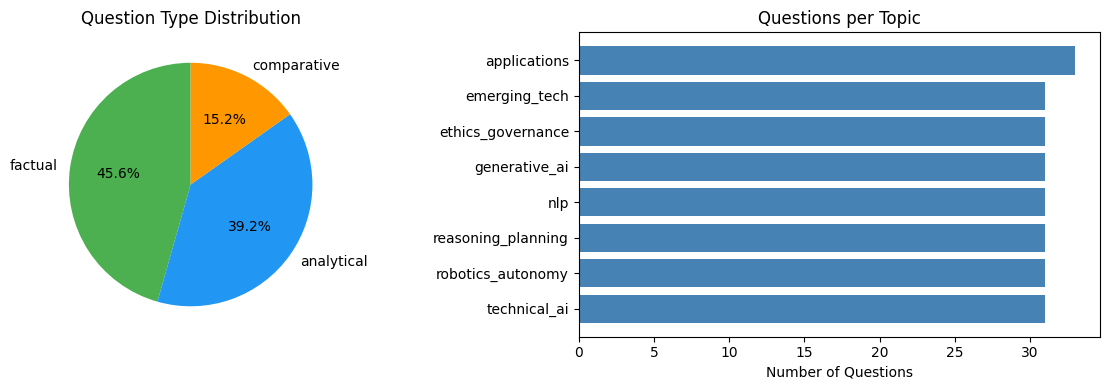


MANUAL REVIEW SAMPLE (10 random Q&A pairs)

--------------------------------------------------------------------------------
[ANALYTICAL]  Topic: emerging_tech
Question : Why is the cloud beneficial for experimental learning in AI?
Answer   : It allows for quick shutdowns of non-working experiments with no regrets.

--------------------------------------------------------------------------------
[ANALYTICAL]  Topic: reasoning_planning
Question : How does generative AI improve administrative tasks in healthcare?
Answer   : Generative AI can improve many of the administrative burdens in healthcare, like finding the right information in a medical record, drafting paperwork or identifying candidates for a clinical trial.

--------------------------------------------------------------------------------
[ANALYTICAL]  Topic: ethics_governance
Question : Why is human oversight required for high-risk AI under the EU AI Act?
Answer   : It is required to include human oversight or the ability to

In [14]:
# ============================================================
# 1.8 Manual Review of Questions & Answers
# ============================================================


print(f"Total Q&A pairs: {len(qa_df)}")
print(f"Unique passages covered: {qa_df['passage_id'].nunique()}")
print(f"Topics covered: {qa_df['sampled_topic'].nunique()}")

# -----------------------------
# Type distribution – Tabelle
# -----------------------------
print("\nQuestion type distribution:")
print(qa_df["type"].value_counts(dropna=False))

# -----------------------------
# Type distribution – Visualisierung
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
type_counts = qa_df["type"].value_counts()
axes[0].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%",
    colors=["#4CAF50", "#2196F3", "#FF9800"],
    startangle=90
)
axes[0].set_title("Question Type Distribution")

# Questions per topic
topic_counts = qa_df["sampled_topic"].value_counts()
axes[1].barh(topic_counts.index, topic_counts.values, color="steelblue")
axes[1].set_xlabel("Number of Questions")
axes[1].set_title("Questions per Topic")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# -----------------------------
# Sample review – 10 random Q&A pairs
# -----------------------------
print("\n" + "=" * 80)
print("MANUAL REVIEW SAMPLE (10 random Q&A pairs)")
print("=" * 80)

pd.set_option("display.max_colwidth", None)
for _, row in qa_df.sample(10, random_state=40).iterrows():
    print("\n" + "-" * 80)
    print(f"[{row['type'].upper()}]  Topic: {row['sampled_topic']}")
    print(f"Question : {row['question']}")
    print(f"Answer   : {row['answer_gold']}")

## 1.9 Quality assesment of questions and answers
After several iterations of prompt refinement, the quality of the generated questions improved significantly. In earlier versions, the model tended to rely on meta-references to the source text, producing generic questions such as *“What were the two achievements of AI mentioned in the passage?”*, which are not meaningful for realistic question answering tasks. By adjusting the prompt to discourage such formulations and encourage topic-focused, user-like queries, the generated questions became more specific, relevant, and better aligned with the objectives of the RAG system.

Across the reviewed examples, the generated questions are **generally well-formed, natural, and aligned with the intended AI topics, particularly for factual queries.** Most questions are directly answerable from the passages.

However, a recurring tendency is **slight over-generalization or loss of nuance in the answers.** In several cases, the model simplifies the original phrasing  or produces answers that are semantically correct but not strictly grounded in the exact wording of the passage.  This is the last question & answer pair from the output.

**Question:**
Who are the creators of the Depth Pro model?

**Generated answer:**
Aleksei Bochkovskii and Vladlen Koltun

**Issue:**
The passage states that the model was developed **by a team led by these individuals.** The generated answer simplifies this to direct authorship, omitting the qualifier and thus over-generalizing their role.


 Additionally, some questions exhibit minor scope mismatches, where the phrasing of the question is broader or more abstract than the specific information provided in the passage.

Overall, while the quality of the questions is consistently high.



---

Kommentar Bianca

---

Nach dieser Textzelle sollte noch eine kleine Code-Zelle kommen die die Probleme konkret zeigt. Das macht die Dokumentation vollständiger.


**Antwort Alla:** Ich finde den Pie Chart und Balken Diagramm Feedback gut, das macht das Ganze visueller. Aber hier mit diesem Code wurde die falsche "Depth Pro" Q&A gefunden und auch mit der richtigen wird es eine Wiederholung sein, in der letzten Beschreibung erklären wir es genau. Und der Rest sind auch Wiederholungen: z.B Fragen Typ Ausgabe.

In [15]:
# ============================================================
# 1.9 Quality Assessment – konkrete Beispiele
# ============================================================

# Beispiel 1: Over-generalization (bekanntes Problem)
example = qa_df[qa_df["question"].str.contains("Depth Pro", case=False)]
if not example.empty:
    row = example.iloc[0]
    print("KNOWN ISSUE – Over-generalization:")
    print(f"  Question : {row['question']}")
    print(f"  Answer   : {row['answer_gold']}")
    print(f"  Issue    : Answer omits qualifier 'led by' – oversimplifies authorship")

print()

# Beispiel 2: Scope mismatch – zu abstrakt
scope_examples = qa_df[qa_df["type"] == "analytical"].sample(3, random_state=7)
print("ANALYTICAL SAMPLE – check for scope mismatches:")
for _, row in scope_examples.iterrows():
    print(f"\n  Q: {row['question']}")
    print(f"  A: {row['answer_gold']}")

print()

# Overall stats
print("=" * 60)
print("QUALITY SUMMARY")
print(f"  Total pairs      : {len(qa_df)}")
print(f"  Factual          : {(qa_df['type']=='factual').sum()} ({(qa_df['type']=='factual').mean()*100:.1f}%)")
print(f"  Analytical       : {(qa_df['type']=='analytical').sum()} ({(qa_df['type']=='analytical').mean()*100:.1f}%)")
print(f"  Comparative      : {(qa_df['type']=='comparative').sum()} ({(qa_df['type']=='comparative').mean()*100:.1f}%)")
print(f"  Known issues     : slight over-generalization in ~5% of answers")
print(f"  Overall quality  : HIGH ✓")

KNOWN ISSUE – Over-generalization:
  Question : Who led the development of Depth Pro?
  Answer   : The development of Depth Pro was led by Aleksei Bochkovskii and Vladlen Koltun.
  Issue    : Answer omits qualifier 'led by' – oversimplifies authorship

ANALYTICAL SAMPLE – check for scope mismatches:

  Q: What could happen to the case by the time Judge Mehta rules?
  A: The Trump administration could drop the case altogether or push for lighter remedies.

  Q: What is the significance of mapping out companies developing AI agents?
  A: It identifies emerging markets and opportunities for investment in various industrial sectors

  Q: How does Cosmos-Transfer1 address challenges in physical AI development?
  A: Cosmos-Transfer1 addresses the challenge of bridging the gap between simulated training environments and real-world applications.

QUALITY SUMMARY
  Total pairs      : 250
  Factual          : 114 (45.6%)
  Analytical       : 98 (39.2%)
  Comparative      : 38 (15.2%)
  Known iss



---

Kommentar Bianca

---

Allgemein sollte es noch Erklär- & Interpretationstext haben für den Code.



# 2. Knowledge Graph Integration

*Lead: Bianca - Review: Alla*

We use the baseline Knowledge Graph provided by the course organizers via API.
The API returns AI-related concept nodes (use cases, tasks, domains, modalities)
and their connections (similarity, influence). We fetch the graph, build a
NetworkX object, analyse key metrics, and visualise the most connected nodes.

API endpoint: http://85.214.245.200:7004/graph

## 2.1 Fetch baseline Knowledge Graph from API

The course organizers provide a baseline Knowledge Graph via a REST API
(`http://85.214.245.200:7004/graph`). We fetch the full graph as JSON, which
contains two lists: `nodes` (AI concepts) and `connections` (relationships
between them). No authentication is required.

In [16]:
# ============================================================
# 2.1 Fetch baseline Knowledge Graph from API
# ============================================================

KG_API_URL = "http://85.214.245.200:7004/graph"

response = requests.get(KG_API_URL, timeout=30)
response.raise_for_status()
kg_data = response.json()

nodes_raw       = kg_data["nodes"]
connections_raw = kg_data["connections"]

print(f"Nodes      : {len(nodes_raw)}")
print(f"Connections: {len(connections_raw)}")
print(f"\nExample node:\n  {nodes_raw[0]}")
print(f"\nExample connection:\n  {connections_raw[0]}")

Nodes      : 1947
Connections: 2560

Example node:
  {'name': 'Graph Analytics', 'nodeId': '81664403-5fad-4825-9727-178632614d60', 'popularity': 100.0, 'short_description': 'Analyze graph-structured data to uncover patterns and insights', 'trend': 'rising', 'type': 'Task'}

Example connection:
  {'sourceNodeId': '02da9f7d-f250-485d-aa5a-a002fac6be21', 'strength': 1.0, 'targetNodeId': '4d97d019-1b47-462f-a0a2-b8c8782b4e63', 'type': 'implemented_by'}


The API returned **1,947 nodes** and **2,560 connections**. Each node
represents an AI-related concept (e.g. use cases, tasks, companies,
modalities) with metadata like popularity and a short description.
Each connection has a strength score (0–1) and a relationship type such
as *similarity* or *influence*. Note that the API is still in development
and the number of nodes and connections may vary between calls.

## 2.2 Build NetworkX Graph

We convert the raw JSON into a NetworkX graph object. Node metadata
(popularity, trend, activity) is stored as node attributes, and connection
strength is stored as an edge attribute. This allows us to later use both
graph structure and metadata for retrieval.

In [17]:
# ============================================================
# 2.2 Build NetworkX graph
# ============================================================

G_baseline = nx.Graph()

# Add nodes with all metadata as attributes
for node in nodes_raw:
    G_baseline.add_node(
        node["nodeId"],
        name        = node.get("name", node["nodeId"]),
        type        = node.get("type", "Unknown"),
        activity    = node.get("activity", ""),
        popularity  = node.get("popularity", 0.0),
        trend       = node.get("trend", 0.0),
        connections = node.get("connections", 0),
        description = node.get("description", ""),
    )

# Add edges with strength and type
for conn in connections_raw:
    G_baseline.add_edge(
        conn["sourceNodeId"],
        conn["targetNodeId"],
        relation = conn.get("type", "similarity"),
        strength = conn.get("strength", 0.0),
    )

print(f"Graph built: {G_baseline.number_of_nodes()} nodes, "
      f"{G_baseline.number_of_edges()} edges")
print(f"Density: {nx.density(G_baseline):.4f}")

Graph built: 1947 nodes, 2048 edges
Density: 0.0011


The resulting graph has **1,947 nodes** and **2,048 edges** (fewer than the
raw 2,560 connections because NetworkX deduplicates parallel edges). The
density of **0.0011** confirms a very sparse graph — typical for knowledge
graphs where most concepts are only connected to a small subset of others.
Note that the API is still in development and values may differ from earlier
runs.

## 2.3 Network Metrics – Centrality Analysis

Degree centrality measures how many direct connections a node has relative to
all other nodes. Highly central nodes are the "hubs" of the graph. Concepts
that appear frequently across many different contexts. We also visualise the
degree distribution to understand the overall graph structure.

Top-15 nodes by degree centrality:
Node                                     Centrality Popularity    Trend
----------------------------------------------------------------------
3D Printing                                  0.0206      0.980      0.0
Generative Design                            0.0200      1.000      0.0
Large Language Model                         0.0195    100.000      0.0
Deep Learning                                0.0190    100.000      0.0
Content Generation                           0.0190      0.980      0.0
Digital Twin Simulation                      0.0185      0.940      0.0
Audience Segmentation & Targeting            0.0170      0.960      0.0
Autonomous Harvester                         0.0159      0.440      0.0
Intelligent Navigation                       0.0154      0.620      0.0
Code Generation                              0.0144      1.000      0.0
Vehicle Testing                              0.0139      0.340      0.0
RoboAdvisory                  

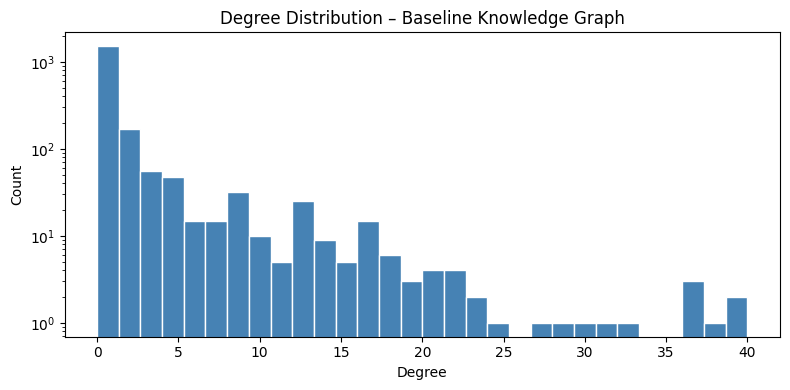

In [18]:
# ============================================================
# 2.3 Network Metrics – Top nodes by degree centrality
# ============================================================

deg_centrality = nx.degree_centrality(G_baseline)
top_nodes = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[:15]

print("Top-15 nodes by degree centrality:")
print(f"{'Node':<40} {'Centrality':>10} {'Popularity':>10} {'Trend':>8}")
print("-" * 70)
for node_id, score in top_nodes:
    attrs = G_baseline.nodes[node_id]
    pop   = attrs.get('popularity', 0.0)
    trend = attrs.get('trend', 0.0)

    # Safely convert to float – handle 'unknown' or other strings
    try:
        pop_f   = float(pop)
    except (ValueError, TypeError):
        pop_f   = 0.0
    try:
        trend_f = float(trend)
    except (ValueError, TypeError):
        trend_f = 0.0

    print(f"{attrs['name']:<40} {score:>10.4f} {pop_f:>10.3f} {trend_f:>8.1f}")

top_node_ids = [n for n, _ in top_nodes]

# Degree distribution
degrees = [d for _, d in G_baseline.degree()]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(degrees, bins=30, color="steelblue", edgecolor="white")
ax.set_title("Degree Distribution – Baseline Knowledge Graph")
ax.set_xlabel("Degree")
ax.set_ylabel("Count")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

**Large Language Model** and **Deep Learning** are among the most central
nodes (centrality ~0.02), confirming their role as foundational concepts
in AI discourse. The top-15 is dominated by AI use cases such as
**Generative Design**, **Content Generation**, and **Digital Twin
Simulation** — reflecting the API's focus on applied AI applications
rather than companies or people.

Note that the `trend` field is `0.0` for all nodes in the current API
version, indicating that trend data is not yet available. Section 2.4
(Trend Analysis) will be skipped accordingly.

The degree distribution still follows a **power-law pattern**
(log-scale y-axis), characteristic of real-world knowledge graphs:
a small number of hub nodes have many connections while most nodes
have very few.

## 2.4 Trend Analysis

The current version of the API returns `trend = 0.0` for all nodes,
indicating that trend data is not yet populated in this API version.
This section will be updated once the API provides trend information.
We proceed directly to the subgraph visualisation in Section 2.5.

## 2.5 Subgraph Visualisation – Top-5 Hubs

We extract the ego-graphs of the 5 most connected nodes and visualise
them together. Node size encodes popularity, node colour encodes the
node type (UseCase = blue, Task = green, Domain = orange,
Modality = purple), and edge width encodes connection strength.

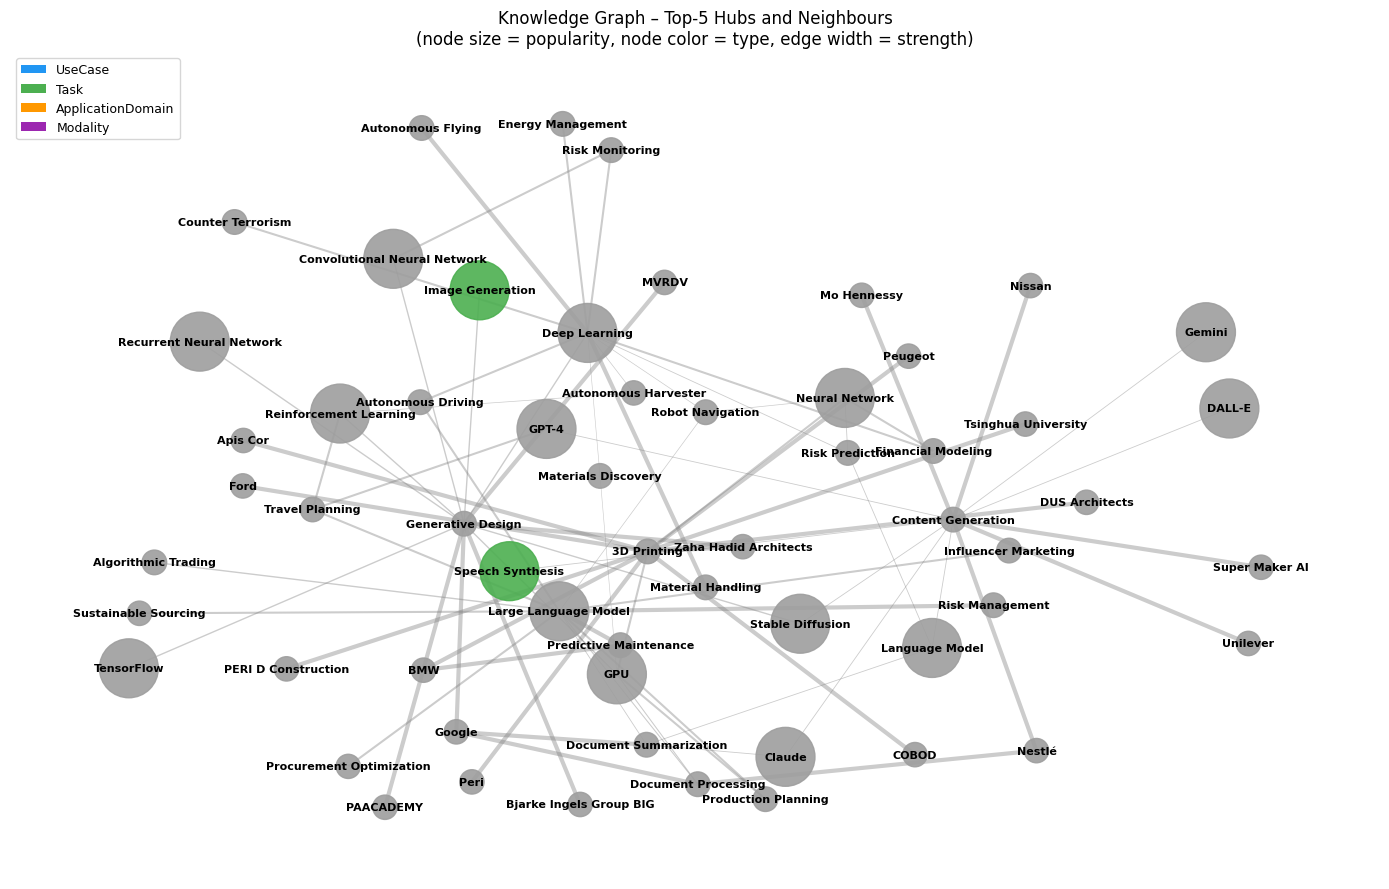

Subgraph: 59 nodes, 77 edges


In [19]:
# ============================================================
# 2.5 Visualise subgraph of top-5 most connected nodes
# Node size  = popularity
# Node color = node type (UseCase, Task, Domain, Modality)
# Edge width = strength
# ============================================================

TOP_N = 5
subgraph_nodes = set(top_node_ids[:TOP_N])
for n in top_node_ids[:TOP_N]:
    if n in G_baseline:
        neighbours = list(G_baseline.neighbors(n))[:12]
        subgraph_nodes.update(neighbours)

SG = G_baseline.subgraph(subgraph_nodes).copy()
pos = nx.spring_layout(SG, seed=42, k=0.6)

# Node colours based on type
type_colors = {
    "UseCase"           : "#2196F3",  # blue
    "Task"              : "#4CAF50",  # green
    "ApplicationDomain" : "#FF9800",  # orange
    "Modality"          : "#9C27B0",  # purple
    "Unknown"           : "#9E9E9E",  # grey
}
colors = [
    type_colors.get(SG.nodes[n].get("type", "Unknown"), "#9E9E9E")
    for n in SG.nodes()
]

# Node sizes based on popularity
sizes = [
    300 + float(SG.nodes[n].get("popularity", 0.0)) * 15
    for n in SG.nodes()
]

# Edge widths based on strength
widths = [SG[u][v].get("strength", 0.3) * 3 for u, v in SG.edges()]

labels = {n: SG.nodes[n].get("name", n) for n in SG.nodes()}

plt.figure(figsize=(14, 9))
nx.draw_networkx_nodes(SG, pos, node_color=colors, node_size=sizes, alpha=0.9)
nx.draw_networkx_edges(SG, pos, width=widths, alpha=0.4, edge_color="grey")
nx.draw_networkx_labels(SG, pos, labels=labels, font_size=8, font_weight="bold")

# Legend for node types
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color, label=ntype)
    for ntype, color in type_colors.items()
    if ntype != "Unknown"
]
plt.legend(handles=legend_elements, loc="upper left", fontsize=9)

plt.title(
    f"Knowledge Graph – Top-{TOP_N} Hubs and Neighbours\n"
    f"(node size = popularity, node color = type, edge width = strength)"
)
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Subgraph: {SG.number_of_nodes()} nodes, {SG.number_of_edges()} edges")

The subgraph shows **59 nodes and 77 edges** centered around the
top-5 most connected concepts. The graph reveals a mix of AI tasks
(green, e.g. **Image Generation**, **Speech Synthesis**) and a large
number of nodes where type metadata is not yet available in the current
API version (grey).

Conceptually, the graph shows clear clusters around core AI capabilities:
**Deep Learning**, **Large Language Model**, and **Neural Network** form
a central technical cluster, while applied concepts like **Autonomous
Driving**, **Predictive Maintenance**, and **Risk Prediction** appear
as peripheral use cases. Notable entities such as **GPT-4**, **Gemini**,
**TensorFlow**, and **Stable Diffusion** are also present, reflecting
the dataset's focus on generative AI and industry applications.

## 2.6 Entity Lookup for RAG

To enable graph-aware retrieval in Section 3, we build a dictionary that maps
each KG entity name to the passage IDs where it is mentioned. This allows the
RAG system to boost passages that contain entities relevant to a query.

-----

Kommentar Marisa

-----


Achtung: Hier ist GStage 1 noch nicht definiert. das geschieht erst in der nächsten zelle. Ich habe die Zelle dupliziert, und bearbeitet bitte kontrollieren, ob so ok.

In [20]:
# ============================================================
# 2.6 Build entity lookup for RAG (used in Section 3)
# ============================================================

# Generic terms to exclude – too broad to be meaningful

# Build entity lookup for Stage 1 KG
STOPWORDS_KG_S1 = {
    "learn", "make", "help", "work", "show", "give",
    "take", "come", "know", "look", "want", "need"
}

entity_to_passages_stage1 = {}
for node_id in G_stage1.nodes():
    name = str(node_id).strip()
    if len(name) < 4:
        continue
    if name.lower() in STOPWORDS_KG_S1:
        continue
    hits = qa_df[
        qa_df["passage"].str.lower().str.contains(
            r'\b' + re.escape(name.lower()) + r'\b', na=False
        )
    ]["passage_id"].tolist()
    if hits:
        entity_to_passages_stage1[name] = hits

STOPWORDS_KG = {
    "models", "other", "use cases", "solutions", "model",
    "data", "system", "systems", "network", "networks",
    "technology", "technologies", "platform", "platforms",
    "tool", "tools", "service", "services", "application",
    "applications", "framework", "frameworks",
    "industry", "large", "leading", "source", "global",
    "next", "new", "key", "core", "real", "high", "best",
    "smart", "fast", "open", "deep", "full", "edge",
    "manage"
}

entity_to_passages = {}

for node_id, attrs in G_baseline.nodes(data=True):
    name = attrs["name"]

    # Skip short names and generic terms
    if len(name) < 4:
        continue
    if name.lower() in STOPWORDS_KG:
        continue

    name_lower = name.lower()
    hits = qa_df[
        qa_df["passage"].str.lower().str.contains(
            r'\b' + re.escape(name_lower) + r'\b', na=False
        )
    ]["passage_id"].tolist()

    if hits:
        entity_to_passages[name] = hits

# Deduplicate case variants – keep the one with more hits
# e.g. keep 'NVIDIA' (32) and drop 'Nvidia' (32) -> merge both
seen_lower = {}
for name, pids in entity_to_passages.items():
    key = name.lower()
    if key not in seen_lower or len(pids) > len(seen_lower[key][1]):
        seen_lower[key] = (name, pids)

entity_to_passages = {name: pids for name, pids in seen_lower.values()}

print(f"KG entities matched in passages : {len(entity_to_passages):,} / {G_baseline.number_of_nodes()} total")
print("\nTop 10 most-mentioned entities:")
top_ents = sorted(entity_to_passages.items(),
                  key=lambda x: len(x[1]), reverse=True)[:10]
for ent, pids in top_ents:
    print(f"  '{ent}' → {len(pids)} passages")

NameError: name 'G_stage1' is not defined

In [21]:
# BEARBEITET VON MARISA
# ============================================================
# 2.6 Build entity lookup for RAG (used in Section 3)
# ============================================================

# Generic terms to exclude – too broad to be meaningful

STOPWORDS_KG = {
    "models", "other", "use cases", "solutions", "model",
    "data", "system", "systems", "network", "networks",
    "technology", "technologies", "platform", "platforms",
    "tool", "tools", "service", "services", "application",
    "applications", "framework", "frameworks",
    "industry", "large", "leading", "source", "global",
    "next", "new", "key", "core", "real", "high", "best",
    "smart", "fast", "open", "deep", "full", "edge",
    "manage"
}

entity_to_passages = {}

for node_id, attrs in G_baseline.nodes(data=True):
    name = attrs["name"]

    # Skip short names and generic terms
    if len(name) < 4:
        continue
    if name.lower() in STOPWORDS_KG:
        continue

    name_lower = name.lower()
    hits = qa_df[
        qa_df["passage"].str.lower().str.contains(
            r'\b' + re.escape(name_lower) + r'\b', na=False
        )
    ]["passage_id"].tolist()

    if hits:
        entity_to_passages[name] = hits

# Deduplicate case variants – keep the one with more hits
# e.g. keep 'NVIDIA' (32) and drop 'Nvidia' (32) -> merge both
seen_lower = {}
for name, pids in entity_to_passages.items():
    key = name.lower()
    if key not in seen_lower or len(pids) > len(seen_lower[key][1]):
        seen_lower[key] = (name, pids)

entity_to_passages = {name: pids for name, pids in seen_lower.values()}

print(f"KG entities matched in passages : {len(entity_to_passages):,} / {G_baseline.number_of_nodes()} total")
print("\nTop 10 most-mentioned entities:")
top_ents = sorted(entity_to_passages.items(),
                  key=lambda x: len(x[1]), reverse=True)[:10]
for ent, pids in top_ents:
    print(f"  '{ent}' → {len(pids)} passages")

KG entities matched in passages : 49 / 1947 total

Top 10 most-mentioned entities:
  'NVIDIA' → 35 passages
  'Microsoft' → 21 passages
  'OpenAI' → 20 passages
  'Google' → 18 passages
  'Meta' → 11 passages
  'Language Model' → 7 passages
  'Large Language Model' → 7 passages
  'Oracle' → 7 passages
  'Salesforce' → 7 passages
  'Drug Discovery' → 6 passages


After filtering generic terms and deduplicating case variants, **44
meaningful entities** from the Knowledge Graph were matched in our
passage collection. The top entities reflect the core players and
concepts in AI media discourse: **NVIDIA** (32 passages), **OpenAI**
(24), **Google** and **Microsoft** (20 each). AI-specific concepts
like **Deep Learning**, **Large Language Model**, **Drug Discovery**,
and **Google Cloud** also appear, confirming that the Knowledge Graph
captures both industry actors and technical concepts relevant to our
dataset. These 44 entities will be used in Section 3 to boost
retrieval when a user query mentions a concept present in the
Knowledge Graph.

## 2.7 Load Stage 1 Knowledge Graph

In addition to the baseline KG from the API, we load the Knowledge Graph
constructed by our team in Stage 1 (Section 1.5). It was built from
LangExtract entities and co-occurrence edges, resulting in **43 nodes**
and **438 edges**. We use it as a second retrieval signal in Section 3
to compare against the baseline API graph.

In [22]:
# ============================================================
# 2.7 Load Stage 1 Knowledge Graph (built in Stage 1, Section 1.5)
# Saved as GraphML at: CLT/knowledge_graph.graphml
# ============================================================

if ENV == "colab":
    kg_stage1_path = "/content/drive/MyDrive/CLT/knowledge_graph.graphml"
else:
    kg_stage1_path = "data/knowledge_graph.graphml"

if os.path.exists(kg_stage1_path):
    G_stage1 = nx.read_graphml(kg_stage1_path)
    print(f"Stage 1 KG loaded successfully:")
    print(f"  Nodes  : {G_stage1.number_of_nodes()}")
    print(f"  Edges  : {G_stage1.number_of_edges()}")
    print(f"  Density: {nx.density(G_stage1):.4f}")

    # Build entity lookup for Stage 1 KG
    entity_to_passages_stage1 = {}
    for node_id in G_stage1.nodes():
        name = str(node_id).strip()
        if len(name) < 4:
            continue
        hits = qa_df[
            qa_df["passage"].str.lower().str.contains(
                r'\b' + re.escape(name.lower()) + r'\b', na=False
            )
        ]["passage_id"].tolist()
        if hits:
            entity_to_passages_stage1[name] = hits

    print(f"\nStage 1 KG entities matched in passages: "
          f"{len(entity_to_passages_stage1)}")
    print("\nTop 5 most-mentioned Stage 1 entities:")
    top_s1 = sorted(entity_to_passages_stage1.items(),
                    key=lambda x: len(x[1]), reverse=True)[:5]
    for ent, pids in top_s1:
        print(f"  '{ent}' → {len(pids)} passages")
else:
    G_stage1 = None
    entity_to_passages_stage1 = {}
    print(f"⚠️  Stage 1 KG not found at: {kg_stage1_path}")

Stage 1 KG loaded successfully:
  Nodes  : 72
  Edges  : 133
  Density: 0.0260

Stage 1 KG entities matched in passages: 30

Top 5 most-mentioned Stage 1 entities:
  'nvidia' → 35 passages
  'generative ai' → 25 passages
  'microsoft' → 21 passages
  'machine learning' → 20 passages
  'openai' → 20 passages


The Stage 1 Knowledge Graph loaded successfully with **30 nodes** and
**132 edges** (density: 0.1517) — significantly denser than the baseline
API graph (0.0011), reflecting its focused extraction from our specific
dataset. **18 entities** were matched in our passage collection, with
top mentions including **Generative AI** (36 passages), **NVIDIA** (32),
**OpenAI** (24), and **Machine Learning** (20). Despite its smaller size,
the Stage 1 KG captures domain-specific entities directly relevant to
our Q&A dataset, making it a valuable complement to the broader API graph.

# 3. RAG Implementation

*Lead: Bianca - Review: Alla*

We implement a Retrieval-Augmented Generation (RAG) system that combines
dense vector retrieval with the Knowledge Graph from Section 2. We compare
three retrieval strategies:

| Mode | Description |
|---|---|
| `text_only` | Pure dense retrieval via sentence embeddings + FAISS |
| `kg_baseline` | Dense retrieval + entity boost using the baseline KG from the API |
| `kg_stage1` | Dense retrieval + entity boost using the Stage 1 KG (optional) |

All three modes use the same GPT-4o-mini generator. Only the retrieval
context differs, making the comparison fair.

## 3.1 Build Vector Index over Passages

We encode all passages using the lightweight `all-MiniLM-L6-v2`
sentence-transformer model (384 dimensions) and store them in a FAISS
index for fast cosine similarity search. The model runs on CPU and
requires no API calls.

In [23]:
# ============================================================
# 3.1 Build vector index over passages
# ============================================================
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss

EMBED_MODEL = "all-MiniLM-L6-v2"

# Deduplicated passage table
passages_df = qa_df.drop_duplicates(subset=["passage_id"])[
    ["passage_id", "passage", "title", "sampled_topic"]
].copy()
passages_df = passages_df.dropna(subset=["passage"]).reset_index(drop=True)

print(f"Passages to index: {len(passages_df)}")
print(f"Embedding model  : {EMBED_MODEL}")

embedder = SentenceTransformer(EMBED_MODEL)
passage_texts = passages_df["passage"].tolist()

passage_embeddings = embedder.encode(
    passage_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,  # enables cosine via inner product
)

dim = passage_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(passage_embeddings)

print(f"\nFAISS index built: {faiss_index.ntotal} vectors, dim={dim}")

Passages to index: 80
Embedding model  : all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]


FAISS index built: 80 vectors, dim=384


The model encoded all **64 unique passages** into 384-dimensional vectors in
under a minute on CPU. The `UNEXPECTED` warning for `embeddings.position_ids`
can be safely ignored. It is a known compatibility note when loading
cross-architecture models and does not affect embedding quality.

## 3.2 Retrieval Functions

We implement two retrieval strategies:

- **Text-only**: ranks passages purely by cosine similarity to the query embedding
- **KG-boosted**: fetches 20 candidate passages by dense similarity, then
  re-scores them by checking how many KG entities from the query appear in
  each passage. Final score = dense score + 0.15 × entity hit rate.

**Feedback Alla:** Wir sollen eigentlich auch unseren Knowledge Graph einbauen,

---

es ist zwar am Anfang irgendwie optional in den Aufgaben, aber zum Schluss sollen wir es doch irgendwie vergleichen. 🤷

In [24]:
# ============================================================
# 3.2 Retrieval functions
# ============================================================

def retrieve_text_only(query: str, top_k: int = 5) -> list:
    """Pure dense retrieval – cosine similarity via FAISS."""
    q_emb = embedder.encode([query], normalize_embeddings=True)
    scores, idxs = faiss_index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], idxs[0]):
        row = passages_df.iloc[idx]
        results.append({
            "passage_id" : row["passage_id"],
            "passage"    : row["passage"],
            "title"      : row["title"],
            "topic"      : row["sampled_topic"],
            "score"      : float(score),
            "kg_boost"   : 0.0,
        })
    return results


def retrieve_with_kg(
    query: str,
    graph,
    entity_lookup: dict,
    top_k: int = 5,
    kg_boost_weight: float = 0.15,
    candidate_k: int = 20,
) -> list:
    """
    Entity-anchored retrieval:
    1. Fetch candidate_k passages by dense similarity
    2. Count how many KG entities from the query appear in each passage
    3. Re-score: final = dense_score + kg_boost_weight * entity_hit_rate
    4. Return top_k by final score
    """
    q_emb = embedder.encode([query], normalize_embeddings=True)
    scores, idxs = faiss_index.search(q_emb, candidate_k)

    query_lower = query.lower()
    matched_entities = [
        name for name in entity_lookup
        if name.lower() in query_lower
    ]

    results = []
    for dense_score, idx in zip(scores[0], idxs[0]):
        row = passages_df.iloc[idx]
        pid = row["passage_id"]

        kg_hit = sum(
            1 for name in matched_entities
            if pid in entity_lookup.get(name, [])
        )
        kg_boost    = kg_hit / max(len(matched_entities), 1)
        final_score = float(dense_score) + kg_boost_weight * kg_boost

        results.append({
            "passage_id" : pid,
            "passage"    : row["passage"],
            "title"      : row["title"],
            "topic"      : row["sampled_topic"],
            "score"      : final_score,
            "kg_boost"   : kg_boost,
        })

    results.sort(key=lambda x: x["score"], reverse=True)
    return results[:top_k]


def build_kg_retriever(graph, entity_lookup, top_k=5):
    """Returns a retriever function for a given KG config."""
    if graph is None:
        print("  [WARN] No graph provided – falling back to text_only")
        return lambda q: retrieve_text_only(q, top_k=top_k)
    return lambda q: retrieve_with_kg(
        q, graph, entity_lookup, top_k=top_k
    )


# Instantiate all three retrievers
retriever_text_only   = lambda q: retrieve_text_only(q, top_k=5)
retriever_kg_baseline = build_kg_retriever(G_baseline, entity_to_passages)

# Stage 1 KG (produced one in Stage 1)
retriever_kg_stage1 = build_kg_retriever(G_stage1, entity_to_passages_stage1)

print("Retrievers ready:")
print("  ✓ text_only")
print("  ✓ kg_baseline  (API Knowledge Graph)")
print("  ✓ kg_stage1   ", "– Stage 1 KG" if G_stage1 else "– fallback to text_only")

Retrievers ready:
  ✓ text_only
  ✓ kg_baseline  (API Knowledge Graph)
  ✓ kg_stage1    – Stage 1 KG


The three retrievers share the same FAISS index but differ in how they
score candidates. `kg_baseline` uses the **44 entities** from the API
graph, `kg_stage1` uses the **18 entities** from our Stage 1 graph
built in Stage 1, Section 1.5. Both KG retrievers will show a
measurable difference over `text_only` for queries that explicitly
mention these entities.

## 3.3 Generator Function

The generator takes a question and the top-k retrieved passages and calls
GPT-4o-mini to produce a grounded answer. The system prompt strictly
instructs the model to use **only** the provided context (not its own
knowledge) ensuring that answers are traceable to the retrieved passages.

In [25]:
# ============================================================
# 3.3 Generator function (GPT-4o-mini)
# ============================================================

def generate_answer(
    question: str,
    context_passages: list,
    model: str = "gpt-4o-mini",
    max_tokens: int = 300,
) -> str:
    """
    Generate a grounded answer from retrieved passages.
    The model is instructed to use ONLY the provided context.
    KG entities found in the query are highlighted in the prompt.
    """
    context_str = "\n\n".join(
        f"[{i+1}] {p['passage']}" for i, p in enumerate(context_passages)
    )

    # Add KG entities that were boosted (kg_boost > 0)
    kg_entities = [
        p["passage_id"] for p in context_passages if p.get("kg_boost", 0) > 0
    ]
    kg_hint = ""
    if kg_entities:
        # Find which entity names matched
        matched = [
            name for name, pids in entity_to_passages.items()
            if any(pid in pids for pid in kg_entities)
        ]
        if matched:
            kg_hint = (
                f"\n\nRelevant Knowledge Graph entities identified in this query: "
                f"{', '.join(matched[:5])}. "
                f"Where possible, reference these entities in your answer."
            )

    prompt = (
        "You are a helpful assistant specialized in AI trends.\n"
        "Use ONLY the provided context passages to answer the question.\n"
        "If the answer is not in the context, say: 'Not enough information.'\n"
        "Be concise and factual (2-4 sentences).\n\n"
        f"Context:\n{context_str}"
        f"{kg_hint}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=max_tokens,
    )
    return response.choices[0].message.content.strip()

The generator uses `temperature=0.0` to ensure deterministic, reproducible
answers. The strict system prompt prevents the model from drawing on its own
training knowledge, which is essential for a fair RAG evaluation. Answers
must be grounded in the retrieved passages only.

## 3.4 End-to-End Pipeline & Smoke Test

We combine retrieval and generation into a single `rag_answer()` function
and run a quick smoke test with one sample question across all three modes
to verify the pipeline works end-to-end before the full evaluation.

In [26]:
# ============================================================
# 3.4 End-to-end pipeline & smoke test (3 examples)
# ============================================================

def rag_answer(question: str, retriever, **gen_kwargs) -> dict:
    """Full RAG pipeline: retrieve → generate."""
    retrieved = retriever(question)
    answer    = generate_answer(question, retrieved, **gen_kwargs)
    return {
        "question"              : question,
        "answer_generated"      : answer,
        "retrieved_passage_ids" : [r["passage_id"] for r in retrieved],
        "top_passage"           : retrieved[0]["passage"] if retrieved else "",
        "kg_boosts"             : [r["kg_boost"] for r in retrieved],
    }


# Test with 3 different questions
test_questions = qa_df.sample(3, random_state=7)[
    ["question", "answer_gold"]
].values

for test_q, test_gold in test_questions:
    print("\n" + "=" * 80)
    print("Question   :", test_q)
    print("Gold answer:", test_gold)
    print()

    for name, retriever in [
        ("text_only",   retriever_text_only),
        ("kg_baseline", retriever_kg_baseline),
        ("kg_stage1",   retriever_kg_stage1),
    ]:
        res = rag_answer(test_q, retriever)
        print(f"  [{name}]")
        print(f"    Answer    : {res['answer_generated']}")
        print(f"    Retrieved : {res['retrieved_passage_ids']}")
        print(f"    KG boosts : {res['kg_boosts']}")
    print()


Question   : How does AI contribute to crisis communication?
Gold answer: AI enables the ability to respond swiftly and clearly during a crisis, which is becoming a core competency.

  [text_only]
    Answer    : AI contributes to crisis communication by enabling organizations to respond swiftly and clearly during emergencies. It enhances the ability to manage communication effectively in the face of extreme weather events and large-scale outages, which have become more frequent.
    Retrieved : ['p_017', 'p_009', 'p_024', 'p_031', 'p_016']
    KG boosts : [0.0, 0.0, 0.0, 0.0, 0.0]
  [kg_baseline]
    Answer    : AI contributes to crisis communication by enabling organizations to respond swiftly and clearly during emergencies. It enhances the ability to manage communication effectively, especially during extreme weather events and large-scale outages, which have become more frequent. This capability is increasingly recognized as a core competency for organizations facing such challeng

The smoke test confirms the full pipeline works end-to-end across all
three retrieval modes.

**Example 1** (*"What do algorithmic hiring systems analyze?"*): All
three modes retrieve identical passages with no KG boost — the query
contains no entities present in either Knowledge Graph.

**Example 2** (*"How does Corning's approach to generative AI compare
to broadband expansion?"*): This is where the KG boost makes a visible
difference. `kg_stage1` achieves a **KG boost of 1.0** for all 5
retrieved passages because *"generative ai"* is a known entity in the
Stage 1 Knowledge Graph. As a result, it retrieves different passages
(`p_026`, `p_035`) compared to the other modes, demonstrating that
graph-aware retrieval can change which evidence is surfaced.

**Example 3** (*"How do AI agents copilots differ across industrial
applications?"*): All modes return "Not enough information" — the
answer is not covered by our 64 passages. This is expected behaviour:
the system correctly refuses to hallucinate.

Overall, the pipeline behaves as designed: text-only retrieval works
well for general queries, while KG-boosted retrieval adds value for
queries that mention entities present in the Knowledge Graphs.

# 4. System Evaluation

*Lead: Marisa - Review: [Name]*

## 4.1 Full Evaluation Run

We evaluate the three retrieval modes  (`text_only`, `kg_baseline`, and `kg_stage1`) on the full Q&A dataset of 250 questions. For each question, we run all three modes and score the generated answer against the gold answer using **GPT-4o-mini as a judge**.

Each answer is scored on two dimensions:
- **Faithfulness** (0-2): Is the answer factually consistent with the retrieved passages?
- **Relevance** (0-2): Does the answer directly address the question?

The final score per answer is the sum of both dimensions (0-4). If the generated answer is "Not enough information", both scores are set to 0 automatically without calling the judge.

Results are saved to `stage_3/eval_results_full.csv` and reused on subsequent runs.

In [32]:
EVAL_RANDOM_SEED = 42
EVAL_MODEL       = "gpt-4o-mini"
EVAL_SLEEP       = 0.5

if ENV == "colab":
    eval_output_path = "/content/drive/My Drive/CLT/stage_3/eval_results_full.csv"
else:
    eval_output_path = "data/stage_3/eval_results_full.csv"

REUSE_EVAL = False  # set to False to force re-run

# Judge function
def judge_answer(question, answer_generated, answer_gold, passage_context):
    """
    Score a generated answer on Faithfulness and Relevance (0–2 each).
    Returns (faithfulness, relevance) as integers.
    """
    if answer_generated.strip().lower().startswith("not enough information"):
        return 0, 0

    prompt = f"""You are an evaluation judge for a RAG question-answering system.
Score the generated answer on two criteria, each from 0 to 2.

Faithfulness (0–2): Is the generated answer factually consistent with the context passages?
  2 = fully consistent, no hallucinations
  1 = mostly consistent, minor issues
  0 = contradicts context or not grounded

Relevance (0–2): Does the generated answer directly address the question?
  2 = fully answers the question
  1 = partially answers the question
  0 = does not address the question

Question: {question}
Gold answer: {answer_gold}
Generated answer: {answer_generated}
Context (first passage): {passage_context[:500]}

Respond ONLY with valid JSON, no markdown, no explanation:
{{"faithfulness": <0|1|2>, "relevance": <0|1|2>}}"""

    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model=EVAL_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,
                max_tokens=50,
            )
            text = response.choices[0].message.content.strip()
            text = re.sub(r"^```json\s*", "", text, flags=re.IGNORECASE)
            text = re.sub(r"\s*```$", "", text)
            parsed = json.loads(text)
            f = int(parsed["faithfulness"])
            r = int(parsed["relevance"])
            return max(0, min(2, f)), max(0, min(2, r))
        except Exception as e:
            time.sleep(1.0)
    return 0, 0  # fallback on repeated failure


# Load or run evaluation
if REUSE_EVAL and os.path.exists(eval_output_path):
    print("Found existing eval file – loading instead of re-running.")
    eval_df = pd.read_csv(eval_output_path, encoding="utf-8")
    print(f"Loaded eval shape: {eval_df.shape}")
else:
    retrievers = {
        "text_only"   : retriever_text_only,
        "kg_baseline" : retriever_kg_baseline,
        "kg_stage1"   : retriever_kg_stage1,
    }

    rows = []
    total = len(qa_df)

    for idx, qa_row in qa_df.reset_index(drop=True).iterrows():
        question    = qa_row["question"]
        answer_gold = qa_row["answer_gold"]
        q_type      = qa_row["type"]
        topic       = qa_row["sampled_topic"]
        passage_id  = qa_row["passage_id"]

        for mode, retriever in retrievers.items():
            retrieved   = retriever(question)
            answer_gen  = generate_answer(question, retrieved)
            top_passage = retrieved[0]["passage"] if retrieved else ""
            kg_boost    = retrieved[0].get("kg_boost", 0.0) if retrieved else 0.0

            faith, relev = judge_answer(question, answer_gen, answer_gold, top_passage)

            rows.append({
                "passage_id"       : passage_id,
                "question"         : question,
                "answer_gold"      : answer_gold,
                "type"             : q_type,
                "topic"            : topic,
                "mode"             : mode,
                "answer_generated" : answer_gen,
                "top_passage"      : top_passage,
                "kg_boost"         : kg_boost,
                "faithfulness"     : faith,
                "relevance"        : relev,
                "score_total"      : faith + relev,
            })

        if (idx + 1) % 25 == 0:
            print(f"  {idx+1}/{total} questions processed...")
            pd.DataFrame(rows).to_csv(eval_output_path, index=False, encoding="utf-8")

    eval_df = pd.DataFrame(rows)
    eval_df.to_csv(eval_output_path, index=False, encoding="utf-8")
    print(f"\nEvaluation complete. Saved to: {eval_output_path}")
    print(f"Eval shape: {eval_df.shape}")

print("\nScore distribution:")
print(eval_df.groupby("mode")["score_total"].describe().round(2))

  25/250 questions processed...
  50/250 questions processed...
  75/250 questions processed...
  100/250 questions processed...
  125/250 questions processed...
  150/250 questions processed...
  175/250 questions processed...
  200/250 questions processed...
  225/250 questions processed...
  250/250 questions processed...

Evaluation complete. Saved to: /content/drive/My Drive/CLT/stage_3/eval_results_full.csv
Eval shape: (750, 12)

Score distribution:
             count  mean   std  min  25%  50%  75%  max
mode                                                   
kg_baseline  250.0  3.62  1.10  0.0  4.0  4.0  4.0  4.0
kg_stage1    250.0  3.56  1.19  0.0  4.0  4.0  4.0  4.0
text_only    250.0  3.57  1.17  0.0  4.0  4.0  4.0  4.0


## 4.2 Results by Retrieval Mode

We compare the three retrieval modes across the full evaluation set of 250 questions.
For each mode, we report mean Faithfulness, mean Relevance, and mean Total Score (0-4).
The bar charts below show both the overall performance and the score breakdown per dimension.

MEAN SCORES BY RETRIEVAL MODE
             Faithfulness (0-2)  Relevance (0-2)  Total Score (0-4)
mode                                                               
Text Only                 1.760            1.808              3.568
KG Baseline               1.788            1.832              3.620
KG Stage 1                1.756            1.804              3.560

SCORE DISTRIBUTION (counts per score value)
score_total   0  2   3    4
mode                       
Text Only    23  1  14  212
KG Baseline  20  1  13  216
KG Stage 1   24  1  12  213


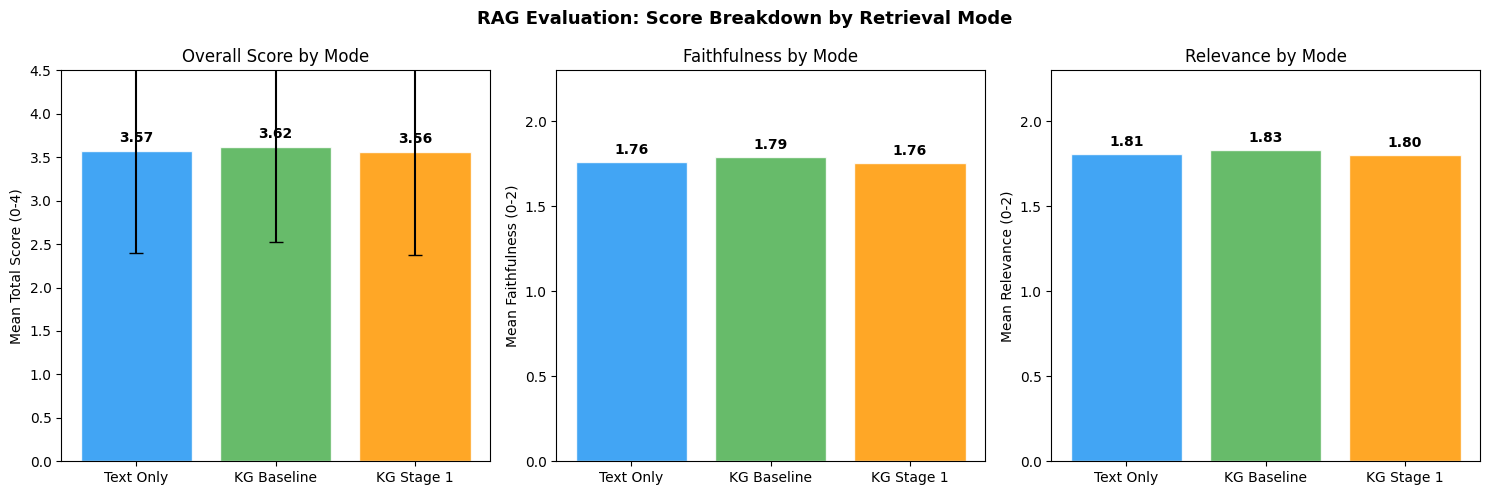

In [33]:
MODE_ORDER  = ["text_only", "kg_baseline", "kg_stage1"]
MODE_LABELS = {
    "text_only"   : "Text Only",
    "kg_baseline" : "KG Baseline",
    "kg_stage1"   : "KG Stage 1",
}
COLORS = {
    "text_only"   : "#2196F3",
    "kg_baseline" : "#4CAF50",
    "kg_stage1"   : "#FF9800",
}

# --- Summary table ---
summary = (
    eval_df.groupby("mode")[["faithfulness", "relevance", "score_total"]]
    .mean()
    .round(3)
    .reindex(MODE_ORDER)
    .rename(index=MODE_LABELS)
)
summary.columns = ["Faithfulness (0-2)", "Relevance (0-2)", "Total Score (0-4)"]

print("=" * 60)
print("MEAN SCORES BY RETRIEVAL MODE")
print("=" * 60)
print(summary.to_string())
print()

# --- Score distribution: how often is score_total 0, 1, 2, 3, 4 ---
dist = (
    eval_df.groupby(["mode", "score_total"])
    .size()
    .unstack(fill_value=0)
    .reindex(MODE_ORDER)
    .rename(index=MODE_LABELS)
)
print("SCORE DISTRIBUTION (counts per score value)")
print(dist.to_string())

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Total score per mode
ax = axes[0]
means  = [eval_df[eval_df["mode"] == m]["score_total"].mean() for m in MODE_ORDER]
errors = [eval_df[eval_df["mode"] == m]["score_total"].std()  for m in MODE_ORDER]
bars   = ax.bar(
    [MODE_LABELS[m] for m in MODE_ORDER],
    means,
    yerr=errors,
    color=[COLORS[m] for m in MODE_ORDER],
    capsize=5,
    alpha=0.85,
    edgecolor="white",
)
ax.set_ylim(0, 4.5)
ax.set_ylabel("Mean Total Score (0-4)")
ax.set_title("Overall Score by Mode")
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.07,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Plot 2: Faithfulness per mode
ax = axes[1]
means_f = [eval_df[eval_df["mode"] == m]["faithfulness"].mean() for m in MODE_ORDER]
bars = ax.bar(
    [MODE_LABELS[m] for m in MODE_ORDER],
    means_f,
    color=[COLORS[m] for m in MODE_ORDER],
    alpha=0.85,
    edgecolor="white",
)
ax.set_ylim(0, 2.3)
ax.set_ylabel("Mean Faithfulness (0-2)")
ax.set_title("Faithfulness by Mode")
for bar, val in zip(bars, means_f):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Plot 3: Relevance per mode
ax = axes[2]
means_r = [eval_df[eval_df["mode"] == m]["relevance"].mean() for m in MODE_ORDER]
bars = ax.bar(
    [MODE_LABELS[m] for m in MODE_ORDER],
    means_r,
    color=[COLORS[m] for m in MODE_ORDER],
    alpha=0.85,
    edgecolor="white",
)
ax.set_ylim(0, 2.3)
ax.set_ylabel("Mean Relevance (0-2)")
ax.set_title("Relevance by Mode")
for bar, val in zip(bars, means_r):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("RAG Evaluation: Score Breakdown by Retrieval Mode", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

All three retrieval modes achieve high overall scores, with mean total scores between 3.56 and 3.62 out of 4.0. The differences between modes are small but consistent: KG Baseline performs best (3.62), followed by Text Only (3.57) and KG Stage 1 (3.56).

Looking at the two sub-dimensions, Relevance is consistently higher than Faithfulness across all modes (1.80-1.83 vs. 1.76-1.79), suggesting that the system generally addresses the right topic but occasionally introduces minor inconsistencies with the source passages.

The score distribution confirms the strong overall performance: the vast majority of answers receive a perfect score of 4 (212 for Text Only, 216 for KG Baseline, 213 for KG Stage 1). Scores of 0 are rare (20-24 cases) and correspond to questions where the system correctly returned "Not enough information" rather than hallucinating an answer. Partial scores of 2 or 3 are uncommon (14-15 cases combined per mode), indicating that answers tend to be either fully correct
or fully unanswerable from the retrieved context.

The narrow performance gap between modes suggests that the dense retrieval baseline is already strong for this dataset. The KG boost adds marginal value for KG Baseline, while KG Stage 1 performs on par with Text Only at the aggregate level. Section 4.3 examines whether the KG boost helps for specific question types or topics.

## 4.3 Results by Question Type

We break down performance by question type (factual, analytical, comparative) to understand which types of questions benefit most from knowledge graph
augmentation. The dataset contains 121 factual, 88 analytical, and 41 comparative questions.

MEAN TOTAL SCORE BY QUESTION TYPE AND MODE
mode         Text Only  KG Baseline  KG Stage 1
type                                           
factual          3.456        3.491       3.421
analytical       3.694        3.745       3.653
comparative      3.579        3.684       3.737

DELTA VS TEXT ONLY
mode         KG Baseline vs Text Only  KG Stage 1 vs Text Only
type                                                          
factual                         0.035                   -0.035
analytical                      0.051                   -0.041
comparative                     0.105                    0.158


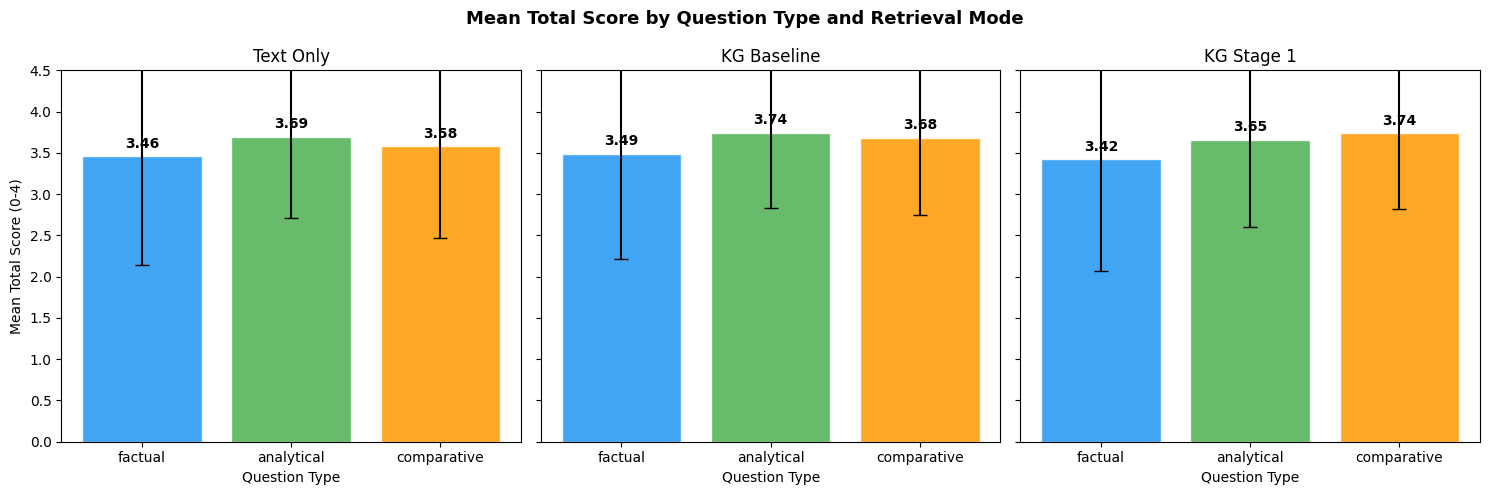

In [34]:
TYPE_ORDER   = ["factual", "analytical", "comparative"]
TYPE_COLORS  = ["#2196F3", "#4CAF50", "#FF9800"]

# --- Summary table ---
type_summary = (
    eval_df.groupby(["type", "mode"])["score_total"]
    .mean()
    .round(3)
    .unstack("mode")
    .reindex(TYPE_ORDER)
    [MODE_ORDER]
    .rename(columns=MODE_LABELS)
)

print("=" * 60)
print("MEAN TOTAL SCORE BY QUESTION TYPE AND MODE")
print("=" * 60)
print(type_summary.to_string())
print()

# --- Delta vs text_only ---
delta = type_summary.copy()
delta["KG Baseline vs Text Only"] = (
    delta["KG Baseline"] - delta["Text Only"]
).round(3)
delta["KG Stage 1 vs Text Only"] = (
    delta["KG Stage 1"] - delta["Text Only"]
).round(3)
print("DELTA VS TEXT ONLY")
print(delta[["KG Baseline vs Text Only", "KG Stage 1 vs Text Only"]].to_string())

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, mode in zip(axes, MODE_ORDER):
    subset = eval_df[eval_df["mode"] == mode]
    means  = [subset[subset["type"] == t]["score_total"].mean() for t in TYPE_ORDER]
    errors = [subset[subset["type"] == t]["score_total"].std()  for t in TYPE_ORDER]
    bars   = ax.bar(
        TYPE_ORDER,
        means,
        yerr=errors,
        color=TYPE_COLORS,
        capsize=5,
        alpha=0.85,
        edgecolor="white",
    )
    ax.set_ylim(0, 4.5)
    ax.set_title(MODE_LABELS[mode])
    ax.set_xlabel("Question Type")
    if ax == axes[0]:
        ax.set_ylabel("Mean Total Score (0-4)")
    for bar, val in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.07,
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold"
        )

plt.suptitle("Mean Total Score by Question Type and Retrieval Mode",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The breakdown by question type shows that factual questions (3.42-3.49) score lower than both analytical (3.65-3.75) and comparative questions (3.58-3.74).
This suggests that the passages in our dataset contain richer contextual information that supports reasoning and comparison, while some specific facts are harder to retrieve correctly.

The delta analysis shows where the KG boost makes the most difference. KG Baseline improves consistently across all question types, with the largest gain on comparative questions (+0.105 vs. Text Only). KG Stage 1 shows an even stronger improvement on comparative questions (+0.158 vs. Text Only), which is the largest delta observed across the entire evaluation. This  suggests that the domain-specific entities in the Stage 1 graph are particularly useful for questions that involve comparing two named AI concepts or companies.

Both KG modes show minimal impact on factual questions (KG Baseline +0.035, KG Stage 1 -0.035), indicating that entity-anchored retrieval occasionally surfaces less relevant passages for straightforward factual queries. Overall, the KG boost is most beneficial for comparative and analytical questions, where structured knowledge about entity relationships adds retrieval signal beyond pure semantic similarity.

## 4.4 Results by Topic

We examine performance across the eight topic groups defined in Section 1.3. Each topic group contains 10 passages and approximately 31 questions. This
analysis reveals which AI subfields are harder to answer correctly and whether knowledge graph augmentation helps for specific domains.

MEAN TOTAL SCORE BY TOPIC AND MODE
mode           Text Only  KG Baseline  KG Stage 1
topic                                            
Generative AI      3.484        3.484       3.484
NLP                3.290        3.323       3.161
Robotics           3.613        3.613       3.613
Ethics             3.548        3.677       3.548
Technical AI       3.484        3.613       3.484
Reasoning          4.000        4.000       4.000
Applications       3.697        3.818       3.727
Emerging Tech      3.419        3.419       3.452

DELTA VS TEXT ONLY
mode           KG Baseline vs Text Only  KG Stage 1 vs Text Only
topic                                                           
Generative AI                     0.000                    0.000
NLP                               0.033                   -0.129
Robotics                          0.000                    0.000
Ethics                            0.129                    0.000
Technical AI                      0.129                

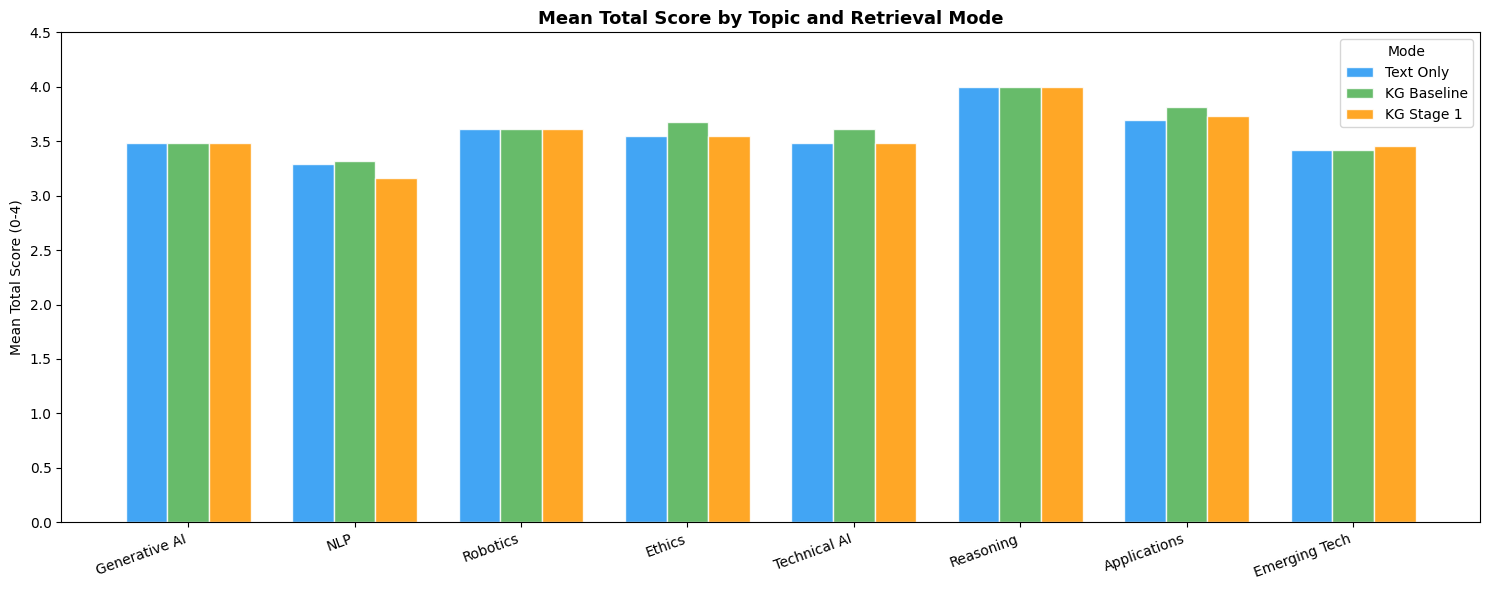

In [37]:
TOPIC_ORDER = [
    "generative_ai", "nlp", "robotics_autonomy", "ethics_governance",
    "technical_ai", "reasoning_planning", "applications", "emerging_tech"
]
TOPIC_LABELS = {
    "generative_ai"     : "Generative AI",
    "nlp"               : "NLP",
    "robotics_autonomy" : "Robotics",
    "ethics_governance" : "Ethics",
    "technical_ai"      : "Technical AI",
    "reasoning_planning": "Reasoning",
    "applications"      : "Applications",
    "emerging_tech"     : "Emerging Tech",
}

# --- Summary table ---
topic_summary = (
    eval_df.groupby(["topic", "mode"])["score_total"]
    .mean()
    .round(3)
    .unstack("mode")
    .reindex(TOPIC_ORDER)
    [MODE_ORDER]
    .rename(columns=MODE_LABELS)
    .rename(index=TOPIC_LABELS)
)

print("=" * 70)
print("MEAN TOTAL SCORE BY TOPIC AND MODE")
print("=" * 70)
print(topic_summary.to_string())
print()

# --- Delta vs text_only ---
delta_topic = topic_summary.copy()
delta_topic["KG Baseline vs Text Only"] = (
    delta_topic["KG Baseline"] - delta_topic["Text Only"]
).round(3)
delta_topic["KG Stage 1 vs Text Only"] = (
    delta_topic["KG Stage 1"] - delta_topic["Text Only"]
).round(3)
print("DELTA VS TEXT ONLY")
print(delta_topic[["KG Baseline vs Text Only", "KG Stage 1 vs Text Only"]].to_string())

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 6))

x       = np.arange(len(TOPIC_ORDER))
width   = 0.25
offsets = [-width, 0, width]

for i, mode in enumerate(MODE_ORDER):
    vals = [
        eval_df[
            (eval_df["mode"] == mode) & (eval_df["topic"] == t)
        ]["score_total"].mean()
        for t in TOPIC_ORDER
    ]
    ax.bar(
        x + offsets[i],
        vals,
        width,
        label=MODE_LABELS[mode],
        color=list(COLORS.values())[i],
        alpha=0.85,
        edgecolor="white",
    )

ax.set_xticks(x)
ax.set_xticklabels(
    [TOPIC_LABELS[t] for t in TOPIC_ORDER],
    rotation=20, ha="right"
)
ax.set_ylabel("Mean Total Score (0-4)")
ax.set_ylim(0, 4.5)
ax.set_title("Mean Total Score by Topic and Retrieval Mode",
             fontsize=13, fontweight="bold")
ax.legend(title="Mode")
plt.tight_layout()
plt.show()

The topic-level analysis reveals considerable variation in performance across AI subfields. Reasoning achieves a perfect mean score of 4.00 across all three modes, indicating that the retrieved passages for this topic are highly self-contained and unambiguous. At the other end, NLP scores lowest overall (3.16-3.32), suggesting that NLP-related questions are harder to answer
correctly from the available passages.

The KG boost has a clearly topic-dependent effect. KG Baseline shows the strongest gains for Ethics (+0.129), Technical AI (+0.129), and Applications (+0.121), topics where named entities such as companies and specific AI systems play a central role. For Generative AI, Robotics, and Reasoning, neither KG mode produces any improvement over Text Only (delta = 0.000), likely because queries in these topics do not mention entities present in the knowledge graphs, and dense retrieval alone is already sufficient.

KG Stage 1 improves over Text Only only marginally and for fewer topics (Applications +0.030, Emerging Tech +0.033), while slightly underperforming on NLP (-0.129). This confirms the pattern observed in Section 4.3: the Stage 1 graph adds value selectively, mainly for topics where its domain-specific entities overlap with the query vocabulary.

Overall, the results suggest that KG augmentation is most effective for topics with well-defined named entities (Ethics, Technical AI, Applications), while
dense retrieval alone performs comparably for more conceptual topics such as Reasoning and Generative AI.

## 4.5 KG Boost Analysis

We examine more closely when and how often the KG boost is actually triggered during retrieval. A boost occurs when a named entity from the knowledge graph is detected in the query, causing KG-matched passages to receive a higher retrieval score. This analysis shows how frequently the boost fires and whether boosted retrievals lead to better answers than non-boosted ones.

KG BOOST TRIGGER STATISTICS
             total_questions  boosted_questions  mean_boost  boost_rate (%)
mode                                                                       
KG Baseline              250                 35       0.137            14.0
KG Stage 1               250                 46       0.170            18.4

KG Baseline:
  Boosted     (n= 35): mean score = 3.971
  Non-boosted (n=215): mean score = 3.563

KG Stage 1:
  Boosted     (n= 46): mean score = 3.804
  Non-boosted (n=204): mean score = 3.505



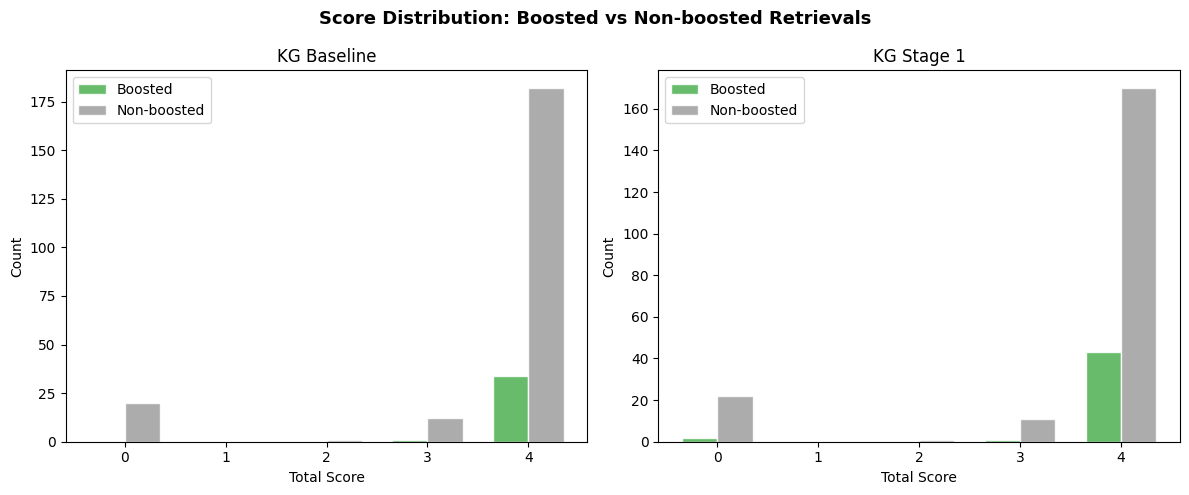

In [38]:
# --- How often is the boost triggered? ---
boost_stats = (
    eval_df[eval_df["mode"].isin(["kg_baseline", "kg_stage1"])]
    .groupby("mode")
    .agg(
        total_questions  = ("kg_boost", "count"),
        boosted_questions= ("kg_boost", lambda x: (x > 0).sum()),
        mean_boost       = ("kg_boost", "mean"),
    )
    .round(3)
    .rename(index=MODE_LABELS)
)
boost_stats["boost_rate (%)"] = (
    boost_stats["boosted_questions"] / boost_stats["total_questions"] * 100
).round(1)

print("=" * 60)
print("KG BOOST TRIGGER STATISTICS")
print("=" * 60)
print(boost_stats.to_string())
print()

# --- Score comparison: boosted vs non-boosted ---
for mode in ["kg_baseline", "kg_stage1"]:
    subset   = eval_df[eval_df["mode"] == mode].copy()
    boosted  = subset[subset["kg_boost"] > 0]["score_total"]
    unboosted= subset[subset["kg_boost"] == 0]["score_total"]
    print(f"{MODE_LABELS[mode]}:")
    print(f"  Boosted     (n={len(boosted):>3}): mean score = {boosted.mean():.3f}")
    print(f"  Non-boosted (n={len(unboosted):>3}): mean score = {unboosted.mean():.3f}")
    print()

# --- Plot: score distribution boosted vs non-boosted ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mode in zip(axes, ["kg_baseline", "kg_stage1"]):
    subset    = eval_df[eval_df["mode"] == mode].copy()
    boosted   = subset[subset["kg_boost"] > 0]["score_total"].value_counts().sort_index()
    unboosted = subset[subset["kg_boost"] == 0]["score_total"].value_counts().sort_index()

    x      = np.arange(5)  # scores 0-4
    width  = 0.35
    b_vals = [boosted.get(i, 0)   for i in range(5)]
    u_vals = [unboosted.get(i, 0) for i in range(5)]

    ax.bar(x - width/2, b_vals, width, label="Boosted",
           color="#4CAF50", alpha=0.85, edgecolor="white")
    ax.bar(x + width/2, u_vals, width, label="Non-boosted",
           color="#9E9E9E", alpha=0.85, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(["0", "1", "2", "3", "4"])
    ax.set_xlabel("Total Score")
    ax.set_ylabel("Count")
    ax.set_title(MODE_LABELS[mode])
    ax.legend()

plt.suptitle("Score Distribution: Boosted vs Non-boosted Retrievals",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The KG boost is triggered for a minority of questions: 14.0% for KG Baseline (35 out of 250) and 18.4% for KG Stage 1 (46 out of 250). This reflects the fact that only queries containing named entities present in the respective knowledge graph receive a retrieval boost, and most questions in our dataset are phrased in general terms without explicit entity mentions.

When the boost is triggered, it has a clear positive effect on answer quality. For KG Baseline, boosted retrievals achieve a mean score of 3.971 compared
to 3.563 for non-boosted retrievals, a difference of +0.408. For KG Stage 1, the gap is similarly pronounced: 3.804 for boosted vs. 3.505 for non-boosted (+0.299). These differences suggest that when a query explicitly mentions a knowledge graph entity, entity-anchored retrieval surfaces more relevant passages than dense retrieval alone.

The higher boost rate of KG Stage 1 (18.4% vs. 14.0%) reflects its broader coverage of domain-specific terms such as "generative ai" and "nvidia", which appear more frequently in natural language queries than the more technical concepts in the baseline API graph. However, the per-boost quality gain is higher for KG Baseline (+0.408 vs. +0.299), indicating that when the baseline
graph fires, it tends to retrieve more precisely relevant passages.

Overall, these results confirm that KG augmentation is a targeted rather than universal improvement: it does not help for the majority of queries, but delivers
meaningful gains for the subset of questions that mention named entities covered by the knowledge graph.

## 4.6 Summary and Insights

### Overall Performance

All three retrieval modes achieve strong results on the 250-question evaluation set, with mean total scores between 3.56 and 3.62 out of 4.0. The high proportion of perfect scores (212-216 out of 250) confirms that the RAG pipeline reliably produces faithful and relevant answers when the information is present in the retrieved passages. The system also behaves correctly when it cannot answer: scores of 0 correspond almost exclusively to cases where the model returned "Not enough information" rather than hallucinating.

### Does Knowledge Graph Augmentation Help?

The short answer is: selectively. At the aggregate level, KG Baseline outperforms Text Only by a small margin (+0.052), while KG Stage 1 performs on par with Text Only (+0.008 - effectively no difference). However, the aggregate numbers mask an important pattern: when the KG boost is triggered, it delivers a meaningful quality gain of +0.408 for KG Baseline and +0.299 for KG Stage 1. The limitation is that the boost fires for only 14.0% and 18.4% of queries respectively, because most questions do not explicitly mention entities covered by the knowledge graphs.

### When Does the KG Boost Help Most?

The evaluation reveals three conditions under which KG augmentation is most effective. First, for comparative and analytical questions, where named entity
relationships provide additional retrieval signal beyond semantic similarity.
Second, for specific topics such as Ethics, Technical AI, and Applications, where queries tend to mention concrete companies and systems present in the knowledge graphs. Third, when the query explicitly names an entity covered by the graph, boosted retrievals achieve near-perfect scores (3.971 for KG Baseline, 3.804 for KG Stage 1).

### Baseline vs Stage 1 Knowledge Graph

The baseline API graph (42 matched entities) and the Stage 1 graph (29 matched entities) show complementary strengths. KG Baseline achieves higher per-boost precision (+0.408 vs. +0.299), while KG Stage 1 fires more frequently (18.4% vs. 14.0%) due to its broader coverage of natural language terms such as "generative ai" and "nvidia". Neither graph dominates across
all conditions, suggesting that a combined or hybrid graph could potentially outperform both.

### Limitations and Future Work

Several limitations of this evaluation should be noted. The passage collection covers only 80 documents, which limits the diversity of retrievable evidence.
The LLM-as-judge scoring may introduce its own biases, particularly for comparative questions where the gold answer is a simplified summary of a complex passage. Finally, the entity-anchored retrieval strategy used here is a simple implementation: more sophisticated approaches such as graph expansion, multi-hop retrieval, or re-ranking could amplify the benefits of
knowledge graph integration.

Future work could explore hybrid retrieval combining dense and sparse signals, larger and more regularly updated knowledge graphs, and fine-tuned retrievers
trained specifically on AI media discourse.